# Parte 1: clasificación de sentimiento con ML clásico (solución convencional)

**Curso:** Aprendizaje de Máquina 2026-20, Universidad de los Andes
**Grupo:** _TODO: nombre del grupo en Kaggle_
**Integrantes:** _TODO: nombres y códigos_

## Objetivo
Predecir el sentimiento **global** (`negativo`, `neutral`, `positivo`) de reseñas de productos en español. La métrica de Kaggle es **accuracy**.

## Restricciones de la Parte 1 (si se incumplen, la nota es 0)
- Solo clasificadores de **scikit-learn**.
- Nada de redes neuronales, transformers ni embeddings preentrenados.
- Representación del texto: bolsa de palabras, TF-IDF, n-gramas.
- Resultados **replicables** a partir de este notebook y del modelo guardado con `joblib`.

## Enfoque de esta versión
Esta copia resuelve el proyecto de la forma **convencional** vista en clase, sin trucos fuera del temario: texto completo → limpieza → bolsa de palabras / TF-IDF / n-gramas → clasificadores de scikit-learn → validación cruzada → una sola evaluación en la prueba propia.

| Paso | Qué enseñaron | Qué significa en este proyecto |
|---|---|---|
| Problema y datos | Comparar siempre contra un modelo trivial | Línea base de 35 % (clase más frecuente) |
| Limpieza | Minúsculas, sin tildes, sin signos ni números | Hecho en 3.7; en 5.4 se justifica con números por qué se conservan signos y números |
| Palabras vacías | "En análisis de sentimiento quitar «no» sería un desastre" | No se quitan, y se mide por qué |
| Raíces | Stemming o lematización, nunca ambos | Se prueba con y sin stemming en español (Snowball) |
| Representación | Bolsa de palabras, n-gramas y TF-IDF | Se comparan; los n-gramas son la respuesta del curso al orden perdido |
| Modelos | Logística, Naive Bayes, árbol, KNN, Random Forest, boosting, votación, stacking | Se comparan todos y se justifica la elección |
| Validación | Separar prueba, validación cruzada dentro de entrenamiento, prueba una sola vez | Se aparta un 20 % de `train.csv` como prueba propia |
| Evaluación | Matriz de confusión, precisión, recall y F1 por clase | No se reporta solo accuracy |
| Cierre | Límites: sin orden, sin negación, sin sinónimos | Se demuestran con ejemplos en la sección 10 |

## Estructura del notebook
1. Configuración
2. Carga de datos
3. Análisis exploratorio y corrección de los datos
4. Partición de los datos y esquema de validación
5. Representación del texto y modelos base
6. Ensambles: votación y stacking
7. Ajuste de hiperparámetros
8. Evaluación y análisis de errores
9. Modelo final
10. Bitácora de envíos y conclusiones
11. Declaración de uso de IA generativa

## 1. Configuración

In [1]:
import re
import time
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from nltk.stem import SnowballStemmer
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier,
                              StackingClassifier, VotingClassifier)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

SEED = 42  # usar en todo lo que tenga azar para que el resultado sea replicable
np.random.seed(SEED)

DATA_DIR = Path("data")
SUB_DIR = Path("submissions")  # archivos de envío a Kaggle
MODEL_DIR = Path("models")     # modelo final guardado con joblib
SUB_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

LABELS = ["negativo", "neutral", "positivo"]

print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| nltk", nltk.__version__)

scikit-learn 1.9.1 | pandas 3.0.6 | nltk 3.10.3


## 2. Carga de datos

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")  # SOLO para predecir al final, nunca para entrenar ni ajustar

X, y = train["text"], train["label"]
print(train.shape, eval_df.shape)
train.head()

(12000, 3) (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


## 3. Análisis exploratorio

En esta sección solo se **observan** los datos para saber qué hay. No se limpia ni se modifica nada: `train` y `eval_df` quedan intactos.

### 3.1 Estructura y calidad básica
¿Cuántas filas y columnas hay, de qué tipo son, hay nulos, textos vacíos o repetidos?

In [3]:
for nombre, df in [("train", train), ("eval", eval_df)]:
    print(f"--- {nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(df.dtypes.to_string())
    print("Nulos por columna:", df.isna().sum().to_dict())
    print("Textos vacíos:", (df["text"].str.strip() == "").sum())
    print("Ids repetidos:", df["id"].duplicated().sum(), "| Textos repetidos:", df["text"].duplicated().sum())
    print()

print("Textos de eval que también aparecen en train:", eval_df["text"].isin(train["text"]).sum())

--- train: 12000 filas, 3 columnas
id       int64
text       str
label      str
Nulos por columna: {'id': 0, 'text': 0, 'label': 0}
Textos vacíos: 0
Ids repetidos: 0 | Textos repetidos: 0

--- eval: 3000 filas, 2 columnas
id      int64
text      str
Nulos por columna: {'id': 0, 'text': 0}
Textos vacíos: 0
Ids repetidos: 0 | Textos repetidos: 0

Textos de eval que también aparecen en train: 0


### 3.2 Distribución de clases
¿Qué valores toma `label` y qué tan balanceadas están las clases? Sirve para saber qué accuracy tendría un modelo que siempre predice la clase más frecuente.

Valores distintos de label: ['negativo', 'neutral', 'positivo']


,reseñas,porcentaje
label,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


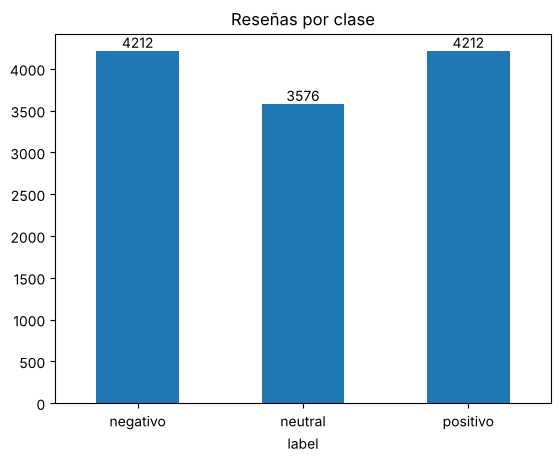

Accuracy de predecir siempre la clase más frecuente: 0.351


In [4]:
conteo = y.value_counts()
resumen_clases = pd.DataFrame({"reseñas": conteo, "porcentaje": (conteo / len(y) * 100).round(1)})
print("Valores distintos de label:", sorted(y.unique()))
display(resumen_clases)

ax = conteo.reindex(LABELS).plot.bar(rot=0, title="Reseñas por clase")
ax.bar_label(ax.containers[0])
plt.show()

print("Accuracy de predecir siempre la clase más frecuente:", round(conteo.max() / len(y), 3))

### 3.3 Longitud de las reseñas
¿Qué tan largas son (caracteres, palabras, oraciones)? ¿Cambia la longitud según la clase? ¿Se parecen `train` y `eval`?

Longitud en train (todas las clases):


,caracteres,palabras,oraciones
count,12000.0,12000.0,12000.0
mean,281.4,53.9,3.9
std,69.2,13.2,0.8
min,14.0,3.0,1.0
25%,245.0,47.0,4.0
50%,280.0,54.0,4.0
75%,320.0,61.0,4.0
max,579.0,110.0,7.0


Promedios por clase:


,caracteres,palabras,oraciones
label,,,
negativo,283.7,54.2,3.8
neutral,271.0,52.3,3.9
positivo,287.9,55.0,3.9


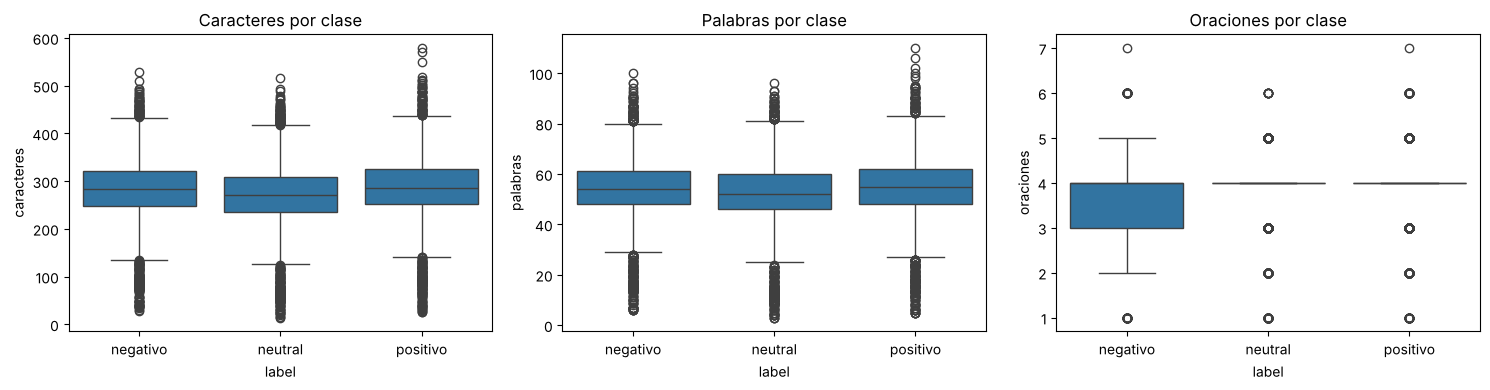

Promedios train vs. eval:


,train,eval
caracteres,281.4,282.5
palabras,53.9,54.2
oraciones,3.9,3.9


In [5]:
def medidas(textos):
    """Tabla con la longitud de cada texto. No modifica los datos originales."""
    return pd.DataFrame({
        "caracteres": textos.str.len(),
        "palabras": textos.str.split().str.len(),
        "oraciones": textos.str.count(r"[.!?]+"),
    })

largos = medidas(X).assign(label=y)
print("Longitud en train (todas las clases):")
display(largos.describe().round(1))
print("Promedios por clase:")
display(largos.groupby("label").mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["caracteres", "palabras", "oraciones"]):
    sns.boxplot(data=largos, x="label", y=col, order=LABELS, ax=ax)
    ax.set_title(f"{col.capitalize()} por clase")
plt.tight_layout(); plt.show()

print("Promedios train vs. eval:")
display(pd.DataFrame({"train": medidas(X).mean(), "eval": medidas(eval_df["text"]).mean()}).round(1))

### 3.4 Leer ejemplos
Leer reseñas reales de cada clase es la parte más importante del EDA: aquí se ve cómo están escritas y qué las hace positivas, negativas o neutrales.

In [6]:
for label in LABELS:
    print(f"===== {label}")
    for t in train.loc[y == label, "text"].sample(5, random_state=SEED):
        print("-", t)
    print()

===== negativo
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.
- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.
- Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión el material quedó sólido en general, se siente firme al tocarlo. La duración de la carga terminó siendo mal hecha desde el primer día, y eso que seguí las instrucciones de uso.
- Se lo compré a un familiar hace unos meses, fue regalo de cumpleaños. El envío llegó en tiempo, sin problema, y el paquete venía bien cerrado. La terminación terminó siendo 

In [7]:
# Las reseñas más cortas y las más largas
orden = largos["palabras"].sort_values()
for titulo, idx in [("MÁS CORTAS", orden.index[:5]), ("MÁS LARGAS", orden.index[-3:])]:
    print(f"===== {titulo}")
    for i in idx:
        print(f"[{y[i]} | {largos.loc[i, 'palabras']} palabras] {X[i]}")
    print()

===== MÁS CORTAS
[neutral | 3 palabras] Viene en dorado.
[neutral | 3 palabras] Viene en azul.
[neutral | 3 palabras] Viene en beige.
[neutral | 4 palabras] Viene con dos adaptadores.
[neutral | 4 palabras] Trae adhesivs de regalo.

===== MÁS LARGAS
[positivo | 102 palabras] Me llegó el procesador el jueves por la mañana acá en casa, lo compré la semana pasada y lo trajo la mensajería de siempre. La caja venía cerrada de fábrica, con el manual y los cables aparte en una bolsita. Lo instalé ese mismo día en el escritorio mientras escuchaba música, sin ningún apuro. Por cierto, el soporte técnico se sintió pésimo a decir verdad, anduve preguntando por el chat unas dudas que tuve. En fin, que después de armarlo todo el procesador terminó siendo bien construido para ser honesto, lo dejé corriendo toda la noche y se portó como se esperaba.
[positivo | 106 palabras] Me llego el telefono un martes por la tarde, como tres dias despues de haberlo pedido, y venia en su caja sellada con el cable 

### 3.5 Caracteres y ruido en el texto
¿Qué tipo de caracteres aparecen? Tildes, mayúsculas, números, signos, emojis, enlaces. Esto muestra qué habría que normalizar más adelante (aquí solo se mide, no se corrige).

In [8]:
patrones = {
    "con tildes o ñ": r"[áéíóúüñÁÉÍÓÚÜÑ]",
    "con números": r"\d",
    "con signos ¡ o ¿": r"[¡¿]",
    "con signos ! o ?": r"[!?]",
    "con palabras en MAYÚSCULAS": r"\b[A-ZÁÉÍÓÚÑ]{3,}\b",
    "con enlaces o @": r"https?://|www\.|@",
    "con caracteres fuera del español": r"[^\x00-\x7FáéíóúüñÁÉÍÓÚÜÑ¡¿]",
}
ruido = pd.DataFrame({
    nombre: {
        "train (%)": X.str.contains(p).mean() * 100,
        **{f"{l} (%)": X[y == l].str.contains(p).mean() * 100 for l in LABELS},
        "eval (%)": eval_df["text"].str.contains(p).mean() * 100,
    }
    for nombre, p in patrones.items()
}).T.round(1)
print("Porcentaje de reseñas que contienen cada tipo de carácter:")
display(ruido)

# Inventario de caracteres que no son letras, números ni espacios
from collections import Counter
simbolos = Counter(c for t in X for c in t if not c.isalnum() and not c.isspace())
print("Símbolos presentes en train:", dict(simbolos.most_common()))

Porcentaje de reseñas que contienen cada tipo de carácter:


,train (%),negativo (%),neutral (%),positivo (%),eval (%)
con tildes o ñ,68.7,68.8,67.0,70.1,68.6
con números,9.4,4.8,20.2,4.8,8.0
con signos ¡ o ¿,0.0,0.0,0.1,0.0,0.0
con signos ! o ?,0.0,0.0,0.0,0.0,0.0
con palabras en MAYÚSCULAS,6.2,3.2,12.7,3.7,6.1
con enlaces o @,0.0,0.0,0.0,0.0,0.0
con caracteres fuera del español,0.0,0.0,0.1,0.0,0.0


Símbolos presentes en train: {'.': 46713, ',': 34166, '-': 450, ':': 302, ';': 144, '\xad': 16, '¡': 4, '±': 3, '©': 3, "'": 2, '%': 1}


### 3.6 Vocabulario
¿Cuántas palabras distintas hay, cuáles son las más frecuentes y cuáles aparecen mucho más en una clase que en las otras? ¿Qué tanto vocabulario de `eval` no está en `train`?

In [9]:
# Solo se cuenta para explorar: en minúsculas, sin quitar tildes ni stopwords
contador = CountVectorizer(lowercase=True, binary=True)  # binary=True: cuenta en cuántas reseñas aparece cada palabra
M = contador.fit_transform(X)
palabras = contador.get_feature_names_out()
print("Palabras distintas en train:", len(palabras))

# Porcentaje de reseñas de cada clase que contienen cada palabra
frec = pd.DataFrame({l: np.asarray(M[(y == l).values].mean(axis=0)).ravel() * 100 for l in LABELS}, index=palabras)
frec["todas"] = np.asarray(M.mean(axis=0)).ravel() * 100

print("\nPalabras más frecuentes (% de reseñas que las contienen):")
display(frec.sort_values("todas", ascending=False).head(20).round(1))

for l in LABELS:
    otras = [o for o in LABELS if o != l]
    diferencia = frec[l] - frec[otras].max(axis=1)
    print(f"\nPalabras mucho más frecuentes en '{l}' que en las otras clases:")
    display(frec.loc[diferencia.sort_values(ascending=False).head(15).index, LABELS].round(1))

vocab_eval = set(CountVectorizer(lowercase=True).fit(eval_df["text"]).get_feature_names_out())
nuevas = vocab_eval - set(palabras)
print(f"\nPalabras de eval que no están en train: {len(nuevas)} de {len(vocab_eval)} ({len(nuevas) / len(vocab_eval):.1%})")
print("Ejemplos:", sorted(nuevas)[:30])

Palabras distintas en train: 6035

Palabras más frecuentes (% de reseñas que las contienen):


,negativo,neutral,positivo,todas
en,93.8,95.0,94.3,94.3
la,96.0,90.4,95.9,94.3
de,90.9,89.4,90.3,90.2
lo,90.0,90.6,87.7,89.4
el,89.8,86.8,89.3,88.7
que,69.8,72.5,68.1,70.0
me,72.2,52.7,73.7,66.9
un,56.3,66.2,56.5,59.4
llegó,55.4,57.1,57.8,56.8
por,48.8,63.8,49.6,53.5



Palabras mucho más frecuentes en 'negativo' que en las otras clases:


,negativo,neutral,positivo
pero,9.5,3.7,3.8
eso,27.4,11.3,23.1
sí,16.1,1.7,13.0
unos,26.8,22.8,24.0
muy,10.8,0.2,8.2
es,20.3,18.1,17.4
cuesta,6.9,0.0,4.8
cuatro,28.6,24.2,26.7
hace,36.7,34.8,34.0
mal,7.3,0.7,5.7



Palabras mucho más frecuentes en 'neutral' que en las otras clases:


,negativo,neutral,positivo
caja,21.2,44.8,20.6
paquete,6.3,27.5,6.0
trae,5.1,25.6,4.7
viene,3.3,23.0,3.1
por,48.8,63.8,49.6
no,27.1,40.6,25.9
color,4.2,16.9,3.8
dos,12.0,24.2,11.8
unidades,2.4,14.3,2.3
voltios,2.3,13.1,2.1



Palabras mucho más frecuentes en 'positivo' que en las otras clases:


,negativo,neutral,positivo
mi,40.6,29.9,46.9
uso,54.2,26.0,59.3
casa,44.7,47.6,52.1
aun,7.5,0.6,11.1
casi,23.6,10.5,26.9
verdad,39.5,2.3,41.7
después,13.9,7.4,16.1
tres,36.1,36.0,38.3
sobre,7.7,6.7,9.9
tardes,8.5,3.5,10.6



Palabras de eval que no están en train: 564 de 3481 (16.2%)
Ejemplos: ['540', '60', '800', 'abrri', 'acaban', 'acampar', 'accierto', 'aceite', 'acomodarle', 'acondicioné', 'acondicé', 'aconsejar', 'actividades', 'actualizacion', 'adaptacion', 'afectará', 'afloja', 'aflojando', 'agarraron', 'agencia', 'agregaar', 'agregado', 'agregarle', 'aguantara', 'ajustan', 'ajustarle', 'alargarme', 'alcancó', 'alcanzara', 'almorzamos']


**Conclusiones del EDA**
- **Balance de clases:** `positivo` y `negativo` tienen 4.212 reseñas cada una (35,1 %) y `neutral` 3.576 (29,8 %). Las clases están casi balanceadas, así que la accuracy es una métrica razonable, y el modelo trivial que siempre dice la clase más frecuente acierta el **35,1 %**: ese es el piso a superar.
- **Datos limpios en estructura:** no hay nulos, textos vacíos, ids ni textos repetidos, y ninguna reseña de `eval` aparece en `train`. No hay que eliminar filas.
- **Longitud:** unas 54 palabras y 4 oraciones por reseña, casi igual en las tres clases y en `eval`. La longitud no sirve para separar clases, pero confirma que `train` y `eval` vienen de la misma distribución.
- **Estructura típica de una reseña:** relleno logístico (cuándo llegó, dónde se compró, dónde se guarda), luego una opinión, un conector ("aun así", "pero", "eso sí") y una opinión final. Palabras como "llegó", "días", "casa" o "compré" aparecen en todas las clases por igual: son relleno.
- **Vocabulario por clase:** `neutral` se reconoce por vocabulario descriptivo (caja, paquete, trae, viene, unidades, voltios) y por los números (20 % de las neutrales tiene cifras frente a 5 % de las demás). En cambio, `positivo` y `negativo` comparten casi el mismo vocabulario: "verdad", "calidad", "muy", "diario" o "uso" aparecen con frecuencias parecidas en las dos, porque casi todas las reseñas polares mezclan elogios y quejas.
- **Los conectores aparecen casi igual en positivas y negativas**, así que lo que decide la clase es **qué opinión viene después** del conector, no qué palabras aparecen.
- **Ruido:** el 31 % de las reseñas no usa tildes ni ñ, hay errores de tipeo ("trs dias", "abrri") y 4 reseñas con la codificación dañada. El 16 % del vocabulario de `eval` no aparece en `train`.

**Hipótesis:** separar `neutral` debería ser fácil para una bolsa de palabras (su vocabulario es distinto), pero separar `positivo` de `negativo` será difícil, porque las dos clases usan las mismas palabras y lo que cambia es el **orden** de las opiniones. Se pone a prueba en las secciones 5 y 8.

### 3.7 Corrección de los datos
Con lo que mostró el EDA se corrige **solo** lo que de verdad aparece en los datos. Los textos originales no se tocan: el resultado queda en una columna nueva, `text_limpio`.

| Hallazgo del EDA | Corrección |
|---|---|
| El 31 % de las reseñas no tiene tildes ni ñ ("llego", "tamano") y el resto sí | Quitar tildes y ñ en todas, para que "llegó" y "llego" sean la misma palabra |
| Hay mayúsculas al inicio de oración y en siglas ("USB", "AAA") | Pasar todo a minúsculas |
| 3 reseñas de `train` tienen la codificación dañada ("reseÃ±a", "llegA3") | Reparar esos pares de caracteres ("reseña", "llegó") |
| 1 reseña más tiene un guion invisible (`\xad`) suelto en medio de una palabra | Eliminarlo |

**Lo que no se corrige, y por qué:**
- **Filas:** no se elimina ninguna, porque no hay nulos, textos vacíos ni repetidos.
- **Etiquetas:** solo existen los tres valores esperados.
- **Palabras vacías ("no", "pero", "aun así"):** se conservan, porque cambian el sentido de la opinión.
- **Puntuación:** se conserva en el texto porque marca dónde termina cada oración y hace legible el análisis de errores. Además casi no hay signos con carga emocional (ningún "!" o "?" y solo 4 "¡"): lo que queda son puntos, comas, guiones, dos puntos y punto y coma. El tokenizador por defecto de scikit-learn (`\b\w\w+\b`) ya los ignora al construir la bolsa de palabras, así que conservarlos no agrega ruido.
- **Números:** se conservan; aparecen en el 20 % de las reseñas neutrales frente al 5 % de las positivas y negativas (tabla de 3.5), así que ayudan a reconocer `neutral` ("trae 2 unidades", "220 voltios").
- Las dos decisiones anteriores se comprueban con validación cruzada en la sección 5.4 (con y sin signos, con y sin números).
- **Errores de tipeo ("trs dias", "autonoia"):** no se corrigen, porque no hay una regla segura para adivinar la palabra correcta.

La corrección es una regla fija (no aprende nada de los datos), así que aplicarla también a `eval` no usa `eval` para entrenar.

In [10]:
# Pares que deja una codificación dañada (UTF-8 leído como Latin-1) -> letra correcta
MOJIBAKE = {"Ã¡": "á", "Ã©": "é", "Ã\xad": "í", "Ã³": "ó", "Ãº": "ú", "Ã±": "ñ"}
# Variante en la que además la Ã perdió su tilde: "llegA3" -> "llegó"
MOJIBAKE_DEGRADADO = {"A¡": "á", "A©": "é", "A\xad": "í", "A3": "ó", "A³": "ó", "Aº": "ú", "A±": "ñ"}
PATRON_DEGRADADO = re.compile(r"(?<=[a-zñ])A[¡©\xad3³º±]")  # solo dentro de una palabra, para no tocar "AA" o "AAA"

def reparar_par(coincidencia):
    return MOJIBAKE_DEGRADADO[coincidencia.group()]

def corregir_texto(texto):
    """Devuelve una copia corregida del texto. No modifica el original."""
    for malo, bueno in MOJIBAKE.items():                 # 1. reparar la codificación dañada
        texto = texto.replace(malo, bueno)
    texto = PATRON_DEGRADADO.sub(reparar_par, texto)
    texto = texto.replace("\xad", "")                    # 2. quitar guiones invisibles
    texto = texto.lower()                                # 3. minúsculas
    texto = unicodedata.normalize("NFKD", texto)         # 4. quitar tildes y ñ
    return "".join(c for c in texto if not unicodedata.combining(c))

train["text_limpio"] = train["text"].map(corregir_texto)
eval_df["text_limpio"] = eval_df["text"].map(corregir_texto)

print("Filas en train:", len(train), "| en eval:", len(eval_df), "(no se eliminó ninguna)")
train[["text", "text_limpio", "label"]].head(3)

Filas en train: 12000 | en eval: 3000 (no se eliminó ninguna)


,text,text_limpio,label
0,Lo pedí un martes por la noche y me llegó al d...,lo pedi un martes por la noche y me llego al d...,neutral
1,Se lo compré a un familiar después de pensarla...,se lo compre a un familiar despues de pensarla...,positivo
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedi a mediados de mes y me llego en tres d...,negativo


**Comprobación.** Las mismas medidas del EDA, antes y después de corregir, y ejemplos de cómo cambia el texto.

In [11]:
PATRON_DANADO = r"Ã|(?<=[a-zñ])A[¡©\xad3³º±]|\xad"

def resumen(textos):
    return {
        "reseñas con tildes o ñ": textos.str.contains(r"[áéíóúüñÁÉÍÓÚÜÑ]").sum(),
        "reseñas con mayúsculas": textos.str.contains(r"[A-ZÁÉÍÓÚÑ]").sum(),
        "reseñas con codificación dañada o guion invisible": textos.str.contains(PATRON_DANADO).sum(),
        "palabras distintas": len(CountVectorizer().fit(textos).vocabulary_),
        "textos repetidos": textos.duplicated().sum(),
        "textos vacíos": (textos.str.strip() == "").sum(),
    }

display(pd.DataFrame({
    "train antes": resumen(train["text"]),
    "train después": resumen(train["text_limpio"]),
    "eval antes": resumen(eval_df["text"]),
    "eval después": resumen(eval_df["text_limpio"]),
}))

# Todos los caracteres distintos que quedan después de corregir
print("Caracteres que quedan en train:", "".join(sorted(set("".join(train["text_limpio"])))))
print("Caracteres que quedan en eval: ", "".join(sorted(set("".join(eval_df["text_limpio"])))))

# Palabras de eval que no están en train, antes y después
for col in ["text", "text_limpio"]:
    vocab_train = set(CountVectorizer().fit(train[col]).vocabulary_)
    vocab_eval = set(CountVectorizer().fit(eval_df[col]).vocabulary_)
    nuevas = vocab_eval - vocab_train
    print(f"{col}: {len(nuevas)} de {len(vocab_eval)} palabras de eval no están en train ({len(nuevas) / len(vocab_eval):.1%})")

# Ejemplos: una reseña normal y las que tenían la codificación dañada
danadas = train.index[train["text"].str.contains(PATRON_DANADO)]
for i in [0, *danadas]:
    print(f"\n[{i}] ANTES:   {train.loc[i, 'text'][:160]}")
    print(f"[{i}] DESPUÉS: {train.loc[i, 'text_limpio'][:160]}")

,train antes,train después,eval antes,eval después
reseñas con tildes o ñ,8242,0,2058,0
reseñas con mayúsculas,12000,0,3000,0
reseñas con codificación dañada o guion invisible,4,0,0,0
palabras distintas,6035,5455,3481,3143
textos repetidos,0,0,0,0
textos vacíos,0,0,0,0


Caracteres que quedan en train:  %',-.0123456789:;abcdefghijklmnopqrstuvwxyz
Caracteres que quedan en eval:   ,-.0123456789:;abcdefghijklmnopqrstuvwxyz


text: 564 de 3481 palabras de eval no están en train (16.2%)


text_limpio: 521 de 3143 palabras de eval no están en train (16.6%)

[0] ANTES:   Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo 
[0] DESPUÉS: lo pedi un martes por la noche y me llego al dia siguiente. es el modelo en color negro, el basico de la linea. lo pese en la bascula de la cocina y marca algo 

[716] ANTES:   Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la tarde, unos tres dÃ­as despuÃ©s de la compra. El color es rojo, tal cual se veÃ
[716] DESPUÉS: pues aqui va lo prometido, mi resena del articulo. me llego el martes por la tarde, unos tres dias despues de la compra. el color es rojo, tal cual se veia en l

[3438] ANTES:   Hace poco lo comprÃ© por internet para reemplazar otro que tenÃ­a en casa desde hacÃ­a aÃ±os. El envÃ­o me llegÃ³ en unos cuatro dÃ­as a mi trabajo. SegÃºn la d
[3438] DESPUÉS: hace poco lo compre por internet par

## 4. Partición de los datos y esquema de validación
`eval.csv` no tiene etiquetas, así que no sirve para medir el modelo. Hay que construir la evaluación con `train.csv`.

### 4.1 Conjunto de prueba propio
Se aparta el **20 %** de `train.csv` como prueba, de forma estratificada y con la semilla fija. Ese conjunto no se vuelve a tocar hasta la sección 9.

Los modelos reciben el **texto original** (`text`): la corrección de 3.7 (`corregir_texto`) se aplica dentro del vectorizador como `preprocessor`. Así el modelo guardado incluye la limpieza y se puede usar directamente sobre `eval.csv` sin pasos manuales.

In [12]:
X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    train["text"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)

print(f"Entrenamiento: {len(X_ent)} reseñas | Prueba: {len(X_prueba)} reseñas")
display(pd.DataFrame({
    "train.csv (%)": train["label"].value_counts(normalize=True) * 100,
    "entrenamiento (%)": y_ent.value_counts(normalize=True) * 100,
    "prueba (%)": y_prueba.value_counts(normalize=True) * 100,
}).reindex(LABELS).round(2))

Entrenamiento: 9600 reseñas | Prueba: 2400 reseñas


,train.csv (%),entrenamiento (%),prueba (%)
label,,,
negativo,35.1,35.09,35.12
neutral,29.8,29.80,29.79
positivo,35.1,35.10,35.08


**Decisión.** Se usa un 20 % (2.400 reseñas) como prueba: es suficiente para que la accuracy tenga un margen de error pequeño (con 2.400 ejemplos y accuracy cercana a 0,75, el error estándar es de unos ±0,9 puntos) y deja 9.600 reseñas para entrenar. La división es **estratificada**, así que las tres clases conservan exactamente su proporción original (35,1 / 29,8 / 35,1 %), como muestra la tabla.

### 4.2 Validación cruzada dentro de entrenamiento
Para comparar modelos y elegir hiperparámetros se usa validación cruzada estratificada de 5 pliegues **solo sobre las 9.600 reseñas de entrenamiento**. Cada experimento se guarda en una tabla (`experimentos`) con la accuracy media, su desviación entre pliegues y el F1 macro.

Todo lo que aprende de los datos (vocabulario, pesos IDF) va dentro de un `Pipeline`, para que en cada pliegue se ajuste solo con la parte de entrenamiento de ese pliegue.

In [13]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

experimentos = []  # tabla de experimentos: una fila por modelo evaluado


def evaluar(nombre, modelo, seccion, **detalles):
    """Validación cruzada de 5 pliegues sobre entrenamiento. Guarda y devuelve la fila de resultados."""
    inicio = time.perf_counter()
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    fila = {"sección": seccion, "experimento": nombre, **detalles,
            "accuracy": res["test_accuracy"].mean(), "desv. accuracy": res["test_accuracy"].std(),
            "F1 macro": res["test_f1_macro"].mean(), "segundos": time.perf_counter() - inicio}
    experimentos[:] = [f for f in experimentos if f["experimento"] != nombre]  # si se re-ejecuta, se reemplaza
    experimentos.append(fila)
    print(f"{nombre:<60} accuracy {fila['accuracy']:.4f} ± {fila['desv. accuracy']:.4f} | F1 macro {fila['F1 macro']:.4f}")
    return fila


def tabla(seccion):
    """Experimentos de una sección, de mejor a peor."""
    filas = pd.DataFrame([f for f in experimentos if f["sección"] == seccion]).drop(columns="sección")
    return filas.sort_values("accuracy", ascending=False).round(4).reset_index(drop=True)


# Vectorizadores que aplican la corrección de 3.7 a cada texto antes de tokenizar
def bolsa(**parametros):
    return CountVectorizer(preprocessor=corregir_texto, **parametros)


def tfidf(**parametros):
    return TfidfVectorizer(preprocessor=corregir_texto, **parametros)


def regresion_logistica(C=1.0):
    return LogisticRegression(C=C, max_iter=3000)

**Decisión.**
- **5 pliegues:** cada modelo se entrena con 7.680 reseñas y se valida con 1.920, y se obtienen 5 medidas para ver la variación (la columna `desv. accuracy`). Con más pliegues cada experimento tardaría más sin cambiar las conclusiones.
- **Estratificada:** cada pliegue mantiene la proporción de clases, así ningún pliegue queda con menos neutrales que otro por azar.
- **El modelo no se elige mirando la prueba:** si se probaran muchos modelos contra la prueba y se escogiera el mejor, la prueba dejaría de ser una medida honesta (se estaría ajustando a ella). Por eso todas las decisiones se toman con validación cruzada y la prueba se usa **una sola vez** al final.
- **Diferencias pequeñas:** la desviación entre pliegues ronda ±0,01, así que diferencias de menos de un punto entre dos modelos no se consideran reales; en ese caso se prefiere el modelo más simple.

## 5. Representación del texto y modelos base
En esta sección se recorre el camino visto en clase: de la representación más simple a la más completa, midiendo cada cambio con validación cruzada.

### 5.1 Línea base trivial
Un clasificador que siempre predice la clase más frecuente. Todo lo demás se compara contra ese número.

In [14]:
evaluar("Clase más frecuente (DummyClassifier)", DummyClassifier(strategy="most_frequent"), "5.1")
tabla("5.1")

Clase más frecuente (DummyClassifier)                        accuracy 0.3509 ± 0.0002 | F1 macro 0.1732


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Clase más frecuente (DummyClassifier),0.3509,0.0002,0.1732,1.3165


### 5.2 Bolsa de palabras contra TF-IDF
El mismo clasificador (regresión logística) con cuatro representaciones: conteos, presencia/ausencia (binaria), TF-IDF y TF-IDF con frecuencia sublineal (`1 + log(tf)`).

La regularización interactúa con la escala de las variables: TF-IDF normaliza cada reseña a norma 1, así que sus valores son mucho más pequeños que los conteos y el mismo `C` regulariza mucho más. Para que la comparación sea justa, cada representación se prueba con varios valores de `C` (en `LogisticRegression`, **bajar `C` es regularizar más**).

In [15]:
representaciones = {
    "bolsa de palabras (conteos)": bolsa(),
    "bolsa de palabras (binaria)": bolsa(binary=True),
    "TF-IDF": tfidf(),
    "TF-IDF sublineal": tfidf(sublinear_tf=True),
}
for nombre, vectorizador in representaciones.items():
    for C in [0.3, 1, 3, 10]:
        modelo = Pipeline([("vec", clone(vectorizador)), ("clf", regresion_logistica(C))])
        evaluar(f"{nombre} + LR (C={C})", modelo, "5.2", representación=nombre, C=C)

tabla("5.2").pivot(index="representación", columns="C", values="accuracy")

bolsa de palabras (conteos) + LR (C=0.3)                     accuracy 0.7367 ± 0.0085 | F1 macro 0.7479


bolsa de palabras (conteos) + LR (C=1)                       accuracy 0.7367 ± 0.0068 | F1 macro 0.7483


bolsa de palabras (conteos) + LR (C=3)                       accuracy 0.7356 ± 0.0104 | F1 macro 0.7476


bolsa de palabras (conteos) + LR (C=10)                      accuracy 0.7243 ± 0.0116 | F1 macro 0.7371


bolsa de palabras (binaria) + LR (C=0.3)                     accuracy 0.7364 ± 0.0103 | F1 macro 0.7474


...

TF-IDF sublineal + LR (C=0.3)                                accuracy 0.7162 ± 0.0140 | F1 macro 0.7260


TF-IDF sublineal + LR (C=1)                                  accuracy 0.7279 ± 0.0152 | F1 macro 0.7385


TF-IDF sublineal + LR (C=3)                                  accuracy 0.7351 ± 0.0101 | F1 macro 0.7463


TF-IDF sublineal + LR (C=10)                                 accuracy 0.7356 ± 0.0119 | F1 macro 0.7473


C,0.3,1.0,3.0,10.0
representación,,,,
TF-IDF,0.7109,0.7252,0.7341,0.7365
TF-IDF sublineal,0.7162,0.7279,0.7351,0.7356
bolsa de palabras (binaria),0.7364,0.7368,0.7329,0.7261
bolsa de palabras (conteos),0.7367,0.7367,0.7356,0.7243


`min_df` descarta las palabras que aparecen en menos de `min_df` reseñas (errores de tipeo, palabras raras que no generalizan).

In [16]:
for min_df in [1, 2, 5]:
    vectorizador = tfidf(sublinear_tf=True, min_df=min_df)
    n_terminos = len(clone(vectorizador).fit(X_ent).vocabulary_)
    evaluar(f"TF-IDF sublineal (min_df={min_df}) + LR (C=10)",
            Pipeline([("vec", vectorizador), ("clf", regresion_logistica(10))]), "5.2b",
            min_df=min_df, términos=n_terminos)
tabla("5.2b")

TF-IDF sublineal (min_df=1) + LR (C=10)                      accuracy 0.7356 ± 0.0119 | F1 macro 0.7473


TF-IDF sublineal (min_df=2) + LR (C=10)                      accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


TF-IDF sublineal (min_df=5) + LR (C=10)                      accuracy 0.7354 ± 0.0113 | F1 macro 0.7472


,experimento,min_df,términos,accuracy,desv. accuracy,F1 macro,segundos
0,TF-IDF sublineal (min_df=2) + LR (C=10),2,2967,0.7401,0.0090,0.7515,2.0028
1,TF-IDF sublineal (min_df=1) + LR (C=10),1,4978,0.7356,0.0119,0.7473,1.8981
2,TF-IDF sublineal (min_df=5) + LR (C=10),5,1880,0.7354,0.0113,0.7472,1.6210


**Resultado** - **Con su mejor `C`, las cuatro representaciones empatan** en torno a 0,737: conteos 0,7367 (C = 0,3 o 1), binaria 0,7368 (C = 1), TF-IDF 0,7365 (C = 10) y TF-IDF sublineal 0,7356 (C = 10). Las diferencias son de décimas de punto, muy por debajo de la desviación entre pliegues (≈ ±0,01).
- **Con `C` fijo la comparación engaña:** con el `C = 1` por defecto, TF-IDF da 0,7252 y parece peor que los conteos (0,7367). No es que represente peor, sino que sus valores son más pequeños y el mismo `C` lo regulariza de más. Por eso TF-IDF necesita un `C` más alto (10) y los conteos uno más bajo.
- **`min_df = 2` es la mejor opción:** pasa de 4.978 a 2.967 términos (descarta errores de tipeo y palabras que aparecen una sola vez) y sube a **0,7401**. Con `min_df = 5` (1.880 términos) ya se pierden palabras útiles y baja a 0,7354.

**Decisión:** se sigue con **TF-IDF sublineal con `min_df = 2`**. Empata con la bolsa de palabras, pero el IDF le quita peso a las palabras de relleno que aparecen en casi todas las reseñas ("llego", "dias", "casa") sin tener que quitarlas a mano, y es la representación estándar del curso. El parámetro `sublinear_tf` no cambia nada (las palabras rara vez se repiten dentro de una misma reseña) y se vuelve a revisar en la búsqueda de la sección 7.

### 5.3 N-gramas
Los bigramas y trigramas (`ngram_range`) son la herramienta del curso para recuperar parte del orden: "no me gusto", "aun asi", "me decepciono". Se mide cuánto crece el vocabulario y cuánto cambia el resultado. Como con más términos el modelo tiene más parámetros, se prueba de nuevo con varios `C`.

In [17]:
for ngramas in [(1, 1), (1, 2), (1, 3)]:
    vectorizador = tfidf(sublinear_tf=True, min_df=2, ngram_range=ngramas)
    n_terminos = len(clone(vectorizador).fit(X_ent).vocabulary_)
    for C in [3, 10, 30]:
        evaluar(f"TF-IDF sublineal {ngramas} + LR (C={C})",
                Pipeline([("vec", clone(vectorizador)), ("clf", regresion_logistica(C))]), "5.3",
                n_gramas=str(ngramas), términos=n_terminos, C=C)

resumen_ngramas = tabla("5.3")
display(resumen_ngramas.pivot(index=["n_gramas", "términos"], columns="C", values="accuracy"))

TF-IDF sublineal (1, 1) + LR (C=3)                           accuracy 0.7354 ± 0.0085 | F1 macro 0.7467


TF-IDF sublineal (1, 1) + LR (C=10)                          accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


TF-IDF sublineal (1, 1) + LR (C=30)                          accuracy 0.7338 ± 0.0082 | F1 macro 0.7458


TF-IDF sublineal (1, 2) + LR (C=3)                           accuracy 0.7351 ± 0.0151 | F1 macro 0.7462


TF-IDF sublineal (1, 2) + LR (C=10)                          accuracy 0.7342 ± 0.0139 | F1 macro 0.7457


TF-IDF sublineal (1, 2) + LR (C=30)                          accuracy 0.7349 ± 0.0159 | F1 macro 0.7466


TF-IDF sublineal (1, 3) + LR (C=3)                           accuracy 0.7285 ± 0.0143 | F1 macro 0.7396


TF-IDF sublineal (1, 3) + LR (C=10)                          accuracy 0.7294 ± 0.0153 | F1 macro 0.7410


TF-IDF sublineal (1, 3) + LR (C=30)                          accuracy 0.7276 ± 0.0157 | F1 macro 0.7394


,C,3,10,30
n_gramas,términos,,,
"(1, 1)",2967,0.7354,0.7401,0.7338
"(1, 2)",23076,0.7351,0.7342,0.7349
"(1, 3)",61082,0.7285,0.7294,0.7276


**Resultado** | N-gramas | Términos | Mejor accuracy |
|---|---|---|
| (1, 1) unigramas | 2.967 | **0,7401** (C = 10) |
| (1, 2) + bigramas | 23.076 | 0,7351 (C = 3) |
| (1, 3) + trigramas | 61.082 | 0,7294 (C = 10) |

- **Los n-gramas no ayudan; empeoran un poco.** El vocabulario se multiplica por 8 con bigramas y por 20 con trigramas, pero la accuracy baja medio punto y un punto.
- **Por qué:** los bigramas capturan orden **local** ("no me", "aun asi", "vale la pena"), pero el problema de estas reseñas es el orden **entre cláusulas**: si la opinión buena va antes o después de la mala, y eso pasa a varias palabras u oraciones de distancia, fuera de la ventana de 2 o 3 palabras. Un bigrama como "aun asi" aparece tanto en positivas como en negativas: lo que decide es lo que viene después. Con 9.600 reseñas y 23.000 a 61.000 columnas, el modelo además tiene más parámetros para memorizar el entrenamiento (en la sección 7 se ve: accuracy de entrenamiento 0,997 con bigramas frente a 0,887 con unigramas).
- **No alcanzan para capturar qué opinión va al final.** Es la primera señal del límite de la bolsa de palabras.

**Decisión:** unigramas. Representación base para el resto de la sección: **TF-IDF sublineal, unigramas, `min_df = 2`, regresión logística con `C = 10` (0,7401)**.

### 5.4 Limpieza, palabras vacías y reducción a la raíz
Con la mejor representación hasta ahora se prueban, una a la vez, las decisiones de preprocesamiento que quedaron pendientes.

#### a) Signos y números
En 3.7 se decidió conservar signos y números. Aquí se mide: el tokenizador por defecto (ignora signos, conserva números), uno que además convierte los signos en términos, y uno que descarta los números.

In [18]:
BASE = dict(sublinear_tf=True, min_df=2, ngram_range=(1, 1))  # mejor representación de 5.2 y 5.3
C_BASE = 10

PATRONES = {
    "por defecto: palabras y números, sin signos": r"(?u)\b\w\w+\b",
    "palabras, números y signos": r"(?u)\b\w\w+\b|[.,;:¡!¿?-]",
    "solo palabras, sin números": r"(?u)\b[^\W\d_]{2,}\b",
}
for nombre, patron in PATRONES.items():
    evaluar(f"Tokens: {nombre}",
            Pipeline([("vec", tfidf(token_pattern=patron, **BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4a")
tabla("5.4a")

Tokens: por defecto: palabras y números, sin signos          accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


Tokens: palabras, números y signos                           accuracy 0.7400 ± 0.0085 | F1 macro 0.7514


Tokens: solo palabras, sin números                           accuracy 0.7379 ± 0.0091 | F1 macro 0.7493


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,"Tokens: por defecto: palabras y números, sin s...",0.7401,0.0090,0.7515,1.7949
1,"Tokens: palabras, números y signos",0.7400,0.0085,0.7514,1.7929
2,"Tokens: solo palabras, sin números",0.7379,0.0091,0.7493,1.6571


**Resultado.** Con signos 0,7400, sin números 0,7379, por defecto **0,7401**.
- **Signos:** convertirlos en términos no cambia nada (0,7400 frente a 0,7401). Es lo esperado: en estas reseñas no hay signos con carga emocional ("!" o "?"); solo hay puntos y comas, que aparecen en todas las reseñas y no distinguen clases. Por eso se conservan en el texto (marcan las oraciones y hacen legible el análisis de errores) y se deja que el tokenizador por defecto los ignore.
- **Números:** quitarlos baja 0,2 puntos (0,7401 → 0,7379). Es una diferencia pequeña, dentro del ruido, pero va en la dirección que predijo el EDA (los números son típicos de las reseñas neutrales: "220 voltios", "2 unidades") y conservarlos no cuesta nada. Se conservan.

#### b) Palabras vacías
Se usa la lista de palabras vacías del español de NLTK (escrita aquí sin tildes, igual que el texto corregido, y recortada a sus formas más frecuentes para no depender de una descarga). Se comparan tres opciones: no quitar nada, quitar la lista completa, y quitar la lista **conservando** las palabras de negación, intensidad y contraste.

In [19]:
PALABRAS_VACIAS = """
de la que el en y a los del se las por un para con no una su al lo como mas pero sus le ya o este si porque
esta entre cuando muy sin sobre tambien me hasta hay donde quien desde todo nos durante todos uno les ni
contra otros ese eso ante ellos e esto mi antes algunos que unos yo otro otras otra el tanto esa estos mucho
quienes nada muchos cual poco ella estar estas algunas algo nosotros mis tu te ti tus ellas nosotras os
mio mia mios mias tuyo tuya tuyos tuyas suyo suya suyos suyas nuestro nuestra nuestros nuestras esos esas
estoy estas esta estamos estan este estaba estaban estuve estuvo estado ha he has hemos han haya habia
habian hube hubo habido soy eres es somos son sea fui fue fueron era eran sido siendo tengo tienes tiene
tenemos tienen tenia tenian tuve tuvo tenido teniendo
""".split()
PALABRAS_VACIAS = sorted(set(PALABRAS_VACIAS))

# Palabras de la lista que cambian el sentido de una opinión
NEGACION_Y_CONTRASTE = {"no", "ni", "nada", "sin", "pero", "muy", "mucho", "poco", "mas", "tanto", "contra", "tambien"}
VACIAS_SIN_NEGACION = [p for p in PALABRAS_VACIAS if p not in NEGACION_Y_CONTRASTE]

print(f"Lista completa: {len(PALABRAS_VACIAS)} palabras | conservando negación y contraste: {len(VACIAS_SIN_NEGACION)}")
print("¿'no' está en la lista?", "no" in PALABRAS_VACIAS)

opciones = {"no quitar palabras vacías": None,
            "quitar la lista completa (incluye 'no', 'pero', 'muy')": PALABRAS_VACIAS,
            "quitar la lista, conservando negación y contraste": VACIAS_SIN_NEGACION}
for nombre, lista in opciones.items():
    evaluar(f"Palabras vacías: {nombre}",
            Pipeline([("vec", tfidf(stop_words=lista, **BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4b")
display(tabla("5.4b"))

# Qué le pasa a una frase con cada opción
ejemplo = ["no me gusto nada, pero la bateria es muy buena"]
for nombre, lista in opciones.items():
    print(f"{nombre:<55} ->", clone(tfidf(stop_words=lista)).fit(ejemplo).get_feature_names_out())

Lista completa: 150 palabras | conservando negación y contraste: 138
¿'no' está en la lista? True


Palabras vacías: no quitar palabras vacías                   accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


Palabras vacías: quitar la lista completa (incluye 'no', 'pero', 'muy') accuracy 0.7319 ± 0.0099 | F1 macro 0.7438


Palabras vacías: quitar la lista, conservando negación y contraste accuracy 0.7370 ± 0.0082 | F1 macro 0.7487


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Palabras vacías: no quitar palabras vacías,0.7401,0.0090,0.7515,1.7783
1,"Palabras vacías: quitar la lista, conservando ...",0.7370,0.0082,0.7487,1.7105
2,Palabras vacías: quitar la lista completa (inc...,0.7319,0.0099,0.7438,1.4930


no quitar palabras vacías                               -> ['bateria' 'buena' 'es' 'gusto' 'la' 'me' 'muy' 'nada' 'no' 'pero']
quitar la lista completa (incluye 'no', 'pero', 'muy')  -> ['bateria' 'buena' 'gusto']
quitar la lista, conservando negación y contraste       -> ['bateria' 'buena' 'gusto' 'muy' 'nada' 'no' 'pero']


**Resultado.**

| Opción | Accuracy |
|---|---|
| No quitar palabras vacías | **0,7401** |
| Quitar la lista, conservando negación y contraste | 0,7370 (−0,3) |
| Quitar la lista completa (incluye "no", "pero", "muy") | 0,7319 (−0,8) |

- **Quitar palabras vacías siempre empeora**, y lo hace más cuando se quitan "no", "pero" y "muy". El ejemplo lo muestra: con la lista completa, *"no me gusto nada, pero la bateria es muy buena"* queda reducido a `bateria, buena, gusto`, que es justo lo contrario de lo que dice la frase. Como dijeron en clase, en análisis de sentimiento quitar "no" es un desastre.
- Incluso conservando las negaciones se pierde algo: palabras "vacías" como "me", "mi" o "lo" sí distinguen clases en estos datos (en el EDA, "me" aparece en el 72-74 % de las reseñas polares y solo en el 53 % de las neutrales, porque las neutrales describen el producto y las polares hablan de la experiencia propia).
- TF-IDF ya le da poco peso a las palabras que aparecen en casi todas las reseñas (por el IDF), así que no hace falta quitarlas a mano.

**Decisión:** **no se quitan palabras vacías.**

#### c) Reducción a la raíz (stemming)
Se usa el `SnowballStemmer` del español de NLTK, que recorta sufijos: "decepcionante", "decepciono" y "decepcion" pasan a la misma raíz. Se aplica después de la corrección (texto sin tildes). Como el curso indica, se usa stemming **o** lematización, nunca ambos; aquí se prueba stemming contra no reducir nada.

El tokenizador con raíces se define con `def` en este notebook para que el modelo se pueda guardar y volver a cargar.

In [20]:
STEMMER = SnowballStemmer("spanish")
PATRON_PALABRA = re.compile(r"(?u)\b\w\w+\b")  # el mismo patrón que usa scikit-learn por defecto
_RAICES = {}  # memoria: cada palabra se reduce una sola vez


def tokenizar_con_raiz(texto):
    """Parte el texto en palabras y reduce cada una a su raíz con Snowball."""
    tokens = []
    for palabra in PATRON_PALABRA.findall(texto):
        if palabra not in _RAICES:
            _RAICES[palabra] = STEMMER.stem(palabra)
        tokens.append(_RAICES[palabra])
    return tokens


print(tokenizar_con_raiz(corregir_texto("Me decepcionó: la batería es decepcionante y las decepciones se acumulan")))

evaluar("Sin stemming", Pipeline([("vec", tfidf(**BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4c",
        términos=len(clone(tfidf(**BASE)).fit(X_ent).vocabulary_))
vec_raiz = tfidf(tokenizer=tokenizar_con_raiz, token_pattern=None, **BASE)
evaluar("Con stemming (Snowball)", Pipeline([("vec", vec_raiz), ("clf", regresion_logistica(C_BASE))]), "5.4c",
        términos=len(clone(vec_raiz).fit(X_ent).vocabulary_))
tabla("5.4c")

['me', 'decepcion', 'la', 'bateri', 'es', 'decepcion', 'las', 'decepcion', 'se', 'acumul']


Sin stemming                                                 accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


Con stemming (Snowball)                                      accuracy 0.7335 ± 0.0114 | F1 macro 0.7452


,experimento,términos,accuracy,desv. accuracy,F1 macro,segundos
0,Sin stemming,2967,0.7401,0.0090,0.7515,1.7380
1,Con stemming (Snowball),1810,0.7335,0.0114,0.7452,1.8776


**Decisión** Con stemming 0,7335 frente a **0,7401** sin stemming. El vocabulario baja de 2.967 a 1.810 términos.

- **El stemming empeora 0,7 puntos.** Al juntar formas distintas en una sola raíz se pierden matices que aquí sí importan: por ejemplo, "estrella" (casi siempre en "una estrella", negativa) y "estrellas" ("cinco estrellas", positiva) quedan en la misma raíz ("estrell"), y el modelo ya no puede distinguirlas.
- Además, el texto ya está sin tildes y Snowball está pensado para español con tildes, así que algunos cortes salen raros ("bateria" → "bateri") o no unen lo que deberían ("valió" → "val", pero "valio" → "vali").
- El vocabulario de las reseñas es pequeño (unos 3.000 términos con `min_df = 2`), así que no hay un problema de dispersión que el stemming tenga que resolver.

**Decisión:** **sin stemming** (y, por lo tanto, tampoco lematización: el curso pide usar una u otra, y ninguna hace falta aquí).

**Resumen del preprocesamiento elegido:** minúsculas, sin tildes, codificación reparada (3.7); signos conservados en el texto pero ignorados por el tokenizador; números conservados; palabras vacías conservadas; sin stemming; TF-IDF sublineal de unigramas con `min_df = 2`.

### 5.5 Clasificadores
Con la representación elegida se comparan los clasificadores del curso. Antes de ejecutar, lo que se espera de cada uno con una matriz dispersa de decenas de miles de columnas:

| Clasificador | Qué se espera |
|---|---|
| Regresión logística | Buen resultado: es lineal, maneja bien muchas variables dispersas y la regularización controla el sobreajuste. |
| SVM lineal (`LinearSVC`) | Parecido a la logística: también es un separador lineal, con otra función de pérdida. |
| Naive Bayes (multinomial y complemento) | Rápido y competitivo en texto, pero supone que las palabras son independientes, así que no puede "ver" combinaciones. |
| Árbol de decisión | Peor: cada división usa una sola palabra y con miles de palabras raras sobreajusta. |
| KNN | Peor: en tantas dimensiones casi todas las reseñas están igual de lejos unas de otras (maldición de la dimensionalidad), y las reseñas comparten mucho relleno, así que los "vecinos" se parecen por el relleno y no por la opinión. Se usa distancia coseno, que es la adecuada para TF-IDF. |
| Random Forest | Mejor que un árbol solo, pero cada árbol ve pocas palabras y los árboles no aprovechan bien variables dispersas. |
| Boosting (AdaBoost y Gradient Boosting) | Mejora sobre los árboles, porque cada árbol corrige los errores de los anteriores, pero es lento: Gradient Boosting entrena 3 árboles (uno por clase) en cada una de sus 200 iteraciones. |

Regresión logística (C=10)                                   accuracy 0.7401 ± 0.0090 | F1 macro 0.7515


SVM lineal (LinearSVC, C=0.3)                                accuracy 0.7323 ± 0.0111 | F1 macro 0.7425


Naive Bayes multinomial                                      accuracy 0.7010 ± 0.0104 | F1 macro 0.7134


Naive Bayes complemento                                      accuracy 0.6482 ± 0.0086 | F1 macro 0.6442


Árbol de decisión                                            accuracy 0.5749 ± 0.0098 | F1 macro 0.5867


KNN (k=15, coseno)                                           accuracy 0.6545 ± 0.0079 | F1 macro 0.6559


Random Forest (300 árboles)                                  accuracy 0.6760 ± 0.0097 | F1 macro 0.6828


AdaBoost (300 estimadores)                                   accuracy 0.6133 ± 0.0076 | F1 macro 0.6280


Gradient Boosting (200 árboles)                              accuracy 0.7037 ± 0.0089 | F1 macro 0.7135
Clase más frecuente (referencia)                             accuracy 0.3509 ± 0.0002 | F1 macro 0.1732


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Regresión logística (C=10),0.7401,0.0090,0.7515,1.8849
1,"SVM lineal (LinearSVC, C=0.3)",0.7323,0.0111,0.7425,1.4697
2,Gradient Boosting (200 árboles),0.7038,0.0089,0.7135,96.2289
3,Naive Bayes multinomial,0.7010,0.0104,0.7134,1.2268
4,Random Forest (300 árboles),0.6760,0.0097,0.6828,40.6446
5,"KNN (k=15, coseno)",0.6545,0.0079,0.6559,3.3976
6,Naive Bayes complemento,0.6482,0.0086,0.6442,1.1600
7,AdaBoost (300 estimadores),0.6133,0.0076,0.6280,33.5331
8,Árbol de decisión,0.5749,0.0098,0.5867,4.4493
9,Clase más frecuente (referencia),0.3509,0.0002,0.1732,0.0871


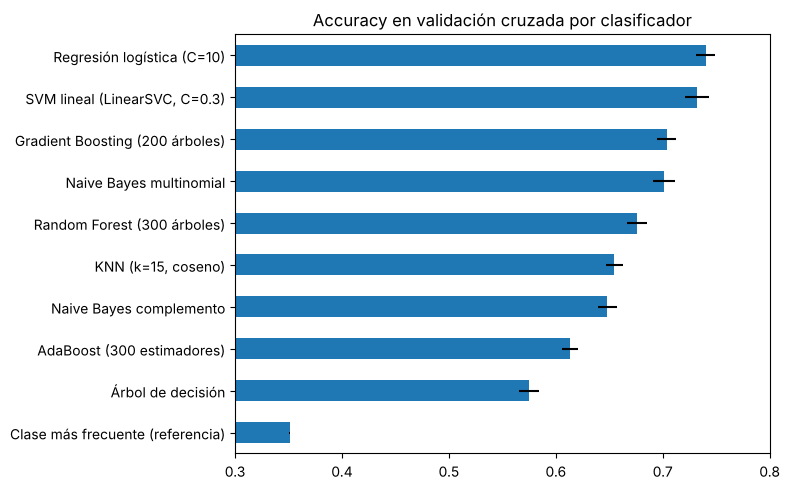

In [21]:
REPRESENTACION = dict(sublinear_tf=True, min_df=2, ngram_range=(1, 1))  # elegida en 5.2-5.4

clasificadores = {
    "Regresión logística (C=10)": regresion_logistica(10),
    "SVM lineal (LinearSVC, C=0.3)": LinearSVC(C=0.3, random_state=SEED),
    "Naive Bayes multinomial": MultinomialNB(),
    "Naive Bayes complemento": ComplementNB(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=SEED),
    "KNN (k=15, coseno)": KNeighborsClassifier(n_neighbors=15, metric="cosine"),
    "Random Forest (300 árboles)": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "AdaBoost (300 estimadores)": AdaBoostClassifier(n_estimators=300, random_state=SEED),
}
for nombre, clf in clasificadores.items():
    evaluar(nombre, Pipeline([("vec", tfidf(**REPRESENTACION)), ("clf", clf)]), "5.5")

evaluar("Gradient Boosting (200 árboles)",
        Pipeline([("vec", tfidf(**REPRESENTACION)),
                  ("clf", GradientBoostingClassifier(n_estimators=200, random_state=SEED))]), "5.5")
evaluar("Clase más frecuente (referencia)", DummyClassifier(strategy="most_frequent"), "5.5")

resultados_clf = tabla("5.5")
display(resultados_clf)
ax = resultados_clf.plot.barh(x="experimento", y="accuracy", xerr="desv. accuracy", legend=False, figsize=(8, 5),
                              title="Accuracy en validación cruzada por clasificador")
ax.invert_yaxis(); ax.set_xlim(0.3, 0.8); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Conclusiones de los modelos base** | Clasificador | Accuracy CV | F1 macro | Segundos (5 pliegues) |
|---|---|---|---|
| **Regresión logística (C=10)** | **0,7401** | **0,7515** | 2 |
| SVM lineal | 0,7323 | 0,7425 | 1 |
| Gradient Boosting | 0,7038 | 0,7135 | 93 |
| Naive Bayes multinomial | 0,7010 | 0,7134 | 1 |
| Random Forest | 0,6760 | 0,6828 | 41 |
| KNN (k=15, coseno) | 0,6545 | 0,6559 | 3 |
| Naive Bayes complemento | 0,6482 | 0,6442 | 1 |
| AdaBoost | 0,6133 | 0,6280 | 33 |
| Árbol de decisión | 0,5749 | 0,5867 | 4 |
| Clase más frecuente | 0,3509 | 0,1732 | 0 |

- **Se cumplen las expectativas:** los modelos lineales (logística y SVM) son los mejores y los más rápidos; Naive Bayes queda cerca pero por debajo; los modelos de árboles y KNN quedan claramente peor. El árbol solo (0,575) sobreajusta; Random Forest lo mejora (0,676) y Gradient Boosting más (0,704), pero tardando 50 veces más que la logística.
- **Todos superan la línea base del 35 %**, pero ninguno pasa de ~0,74.
- **Se elige la regresión logística:** la mejor accuracy y el mejor F1 macro, rápida, y sus coeficientes se pueden leer (sección 8.2).

**¿En qué valor se estanca la bolsa de palabras y por qué?** En **~0,74**, con cualquier representación (5.2), con o sin n-gramas (5.3), con cualquier preprocesamiento (5.4) y con el mejor clasificador. Si el techo no depende del clasificador, el límite está en la **representación**: como se verá en la sección 8, `neutral` ya casi no tiene errores, y todos los errores son entre `positivo` y `negativo`. Estas dos clases usan las mismas palabras ("excelente" y "decepcionante" aparecen en las dos); lo que cambia es **cuál opinión va al final**, y la bolsa de palabras cuenta las palabras sin importar su orden.

### 5.6 Función para generar envíos a Kaggle
La función entrena el modelo con **todo** `train.csv` (las 12.000 reseñas etiquetadas), predice `eval.csv`, valida el formato (`id,answer`, 3.000 filas, mismos ids que `sample_submission.csv`, etiquetas válidas) y guarda el archivo en `submissions/`. También anota el envío en una bitácora con su accuracy de validación cruzada.

Se usa aquí para los tres primeros envíos: el modelo más simple (TF-IDF + LR por defecto), la mejor representación con LR y el mejor de los otros clasificadores.

In [22]:
muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")
bitacora = []  # un registro por envío generado


def generar_envio(modelo, nombre, descripcion, experimento=None):
    """Entrena con todo train.csv, predice eval.csv, valida el formato y guarda submissions/<nombre>.csv."""
    modelo = clone(modelo).fit(train["text"], train["label"])
    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == 3000 and envio["id"].is_unique
    assert set(envio["id"]) == set(muestra["id"]), "los ids no coinciden con sample_submission.csv"
    assert envio["answer"].isin(LABELS).all(), "hay etiquetas no válidas"

    ruta = SUB_DIR / f"{nombre}.csv"
    envio.to_csv(ruta, index=False)
    acc_cv = next((f["accuracy"] for f in experimentos if f["experimento"] == experimento), np.nan)
    bitacora[:] = [b for b in bitacora if b["archivo"] != ruta.name]
    bitacora.append({"archivo": ruta.name, "modelo / cambio": descripcion, "accuracy CV": round(acc_cv, 4)})
    print(f"Guardado {ruta} | predicciones por clase: {envio['answer'].value_counts().to_dict()}")
    return modelo, envio


evaluar("TF-IDF por defecto + LR por defecto", Pipeline([("vec", tfidf()), ("clf", regresion_logistica())]), "5.6")
generar_envio(Pipeline([("vec", tfidf()), ("clf", regresion_logistica())]),
              "conv01_tfidf_lr", "TF-IDF por defecto + regresión logística por defecto",
              "TF-IDF por defecto + LR por defecto")
generar_envio(Pipeline([("vec", tfidf(**REPRESENTACION)), ("clf", regresion_logistica(10))]),
              "conv02_tfidf_min_df2_lr", "TF-IDF sublineal, unigramas, min_df=2 + LR (C=10)",
              "Regresión logística (C=10)")
generar_envio(Pipeline([("vec", tfidf(**REPRESENTACION)), ("clf", LinearSVC(C=0.3, random_state=SEED))]),
              "conv03_tfidf_min_df2_svm", "TF-IDF sublineal, unigramas, min_df=2 + LinearSVC (C=0.3)",
              "SVM lineal (LinearSVC, C=0.3)")
pd.DataFrame(bitacora)

TF-IDF por defecto + LR por defecto                          accuracy 0.7252 ± 0.0123 | F1 macro 0.7359


Guardado submissions/conv01_tfidf_lr.csv | predicciones por clase: {'negativo': 1078, 'positivo': 1073, 'neutral': 849}


Guardado submissions/conv02_tfidf_min_df2_lr.csv | predicciones por clase: {'positivo': 1097, 'negativo': 1068, 'neutral': 835}


Guardado submissions/conv03_tfidf_min_df2_svm.csv | predicciones por clase: {'positivo': 1080, 'negativo': 1065, 'neutral': 855}


,archivo,modelo / cambio,accuracy CV
0,conv01_tfidf_lr.csv,TF-IDF por defecto + regresión logística por d...,0.7252
1,conv02_tfidf_min_df2_lr.csv,"TF-IDF sublineal, unigramas, min_df=2 + LR (C=10)",0.7401
2,conv03_tfidf_min_df2_svm.csv,"TF-IDF sublineal, unigramas, min_df=2 + Linear...",0.7323


## 6. Ensambles: votación y stacking
Los ensambles combinan varios clasificadores con la idea de que sus errores no coincidan. Se combinan los tres mejores modelos lineales de 5.5 (regresión logística, SVM lineal y Naive Bayes), que son rápidos y aprenden cosas algo distintas: la logística y la SVM ponderan las palabras de forma discriminativa y Naive Bayes de forma generativa.

Los tres comparten la misma representación (TF-IDF), así que el vectorizador va una sola vez al inicio del `Pipeline` y el ensamble va después.

### 6.1 Votación
- **Votación dura:** cada modelo vota por una clase y gana la mayoría.
- **Votación suave:** se promedian las probabilidades de cada clase. Requiere `predict_proba`, que `LinearSVC` no tiene, así que se usa logística + Naive Bayes + Random Forest.

In [23]:
def base_lineales():
    return [("lr", regresion_logistica(10)),
            ("svm", LinearSVC(C=0.3, random_state=SEED)),
            ("nb", MultinomialNB())]


evaluar("Votación dura (LR + SVM + NB)",
        Pipeline([("vec", tfidf(**REPRESENTACION)), ("clf", VotingClassifier(base_lineales(), voting="hard"))]), "6")
evaluar("Votación suave (LR + NB + Random Forest)",
        Pipeline([("vec", tfidf(**REPRESENTACION)),
                  ("clf", VotingClassifier([("lr", regresion_logistica(10)), ("nb", MultinomialNB()),
                                            ("rf", RandomForestClassifier(n_estimators=300, random_state=SEED))],
                                           voting="soft"))]), "6")
tabla("6")

Votación dura (LR + SVM + NB)                                accuracy 0.7336 ± 0.0102 | F1 macro 0.7447


Votación suave (LR + NB + Random Forest)                     accuracy 0.7362 ± 0.0109 | F1 macro 0.7472


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Votación suave (LR + NB + Random Forest),0.7362,0.0109,0.7472,41.3254
1,Votación dura (LR + SVM + NB),0.7336,0.0102,0.7447,2.0060


### 6.2 Stacking
En vez de votar, un **metamodelo** (regresión logística) aprende a combinar las salidas de los modelos base. Para que el metamodelo no aprenda de predicciones hechas sobre los mismos datos con que se entrenaron los modelos base, `StackingClassifier` genera esas salidas con una validación cruzada interna (5 pliegues).

In [24]:
evaluar("Stacking (LR + SVM + NB -> LR)",
        Pipeline([("vec", tfidf(**REPRESENTACION)),
                  ("clf", StackingClassifier(base_lineales(), final_estimator=LogisticRegression(max_iter=3000),
                                             cv=StratifiedKFold(5, shuffle=True, random_state=SEED)))]), "6")

comparacion = pd.concat([tabla("6"), resultados_clf.head(3)]).sort_values("accuracy", ascending=False)
display(comparacion[["experimento", "accuracy", "desv. accuracy", "F1 macro", "segundos"]].reset_index(drop=True))

generar_envio(Pipeline([("vec", tfidf(**REPRESENTACION)),
                        ("clf", StackingClassifier(base_lineales(), final_estimator=LogisticRegression(max_iter=3000),
                                                   cv=StratifiedKFold(5, shuffle=True, random_state=SEED)))]),
              "conv04_stacking", "Stacking (LR + SVM + NB -> LR) sobre TF-IDF sublineal, min_df=2",
              "Stacking (LR + SVM + NB -> LR)")
pd.DataFrame(bitacora)

Stacking (LR + SVM + NB -> LR)                               accuracy 0.7420 ± 0.0132 | F1 macro 0.7540


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Stacking (LR + SVM + NB -> LR),0.7420,0.0132,0.7540,5.5536
1,Regresión logística (C=10),0.7401,0.0090,0.7515,1.8849
2,Votación suave (LR + NB + Random Forest),0.7362,0.0109,0.7472,41.3254
3,Votación dura (LR + SVM + NB),0.7336,0.0102,0.7447,2.0060
4,"SVM lineal (LinearSVC, C=0.3)",0.7323,0.0111,0.7425,1.4697
5,Gradient Boosting (200 árboles),0.7038,0.0089,0.7135,96.2289


Guardado submissions/conv04_stacking.csv | predicciones por clase: {'positivo': 1095, 'negativo': 1080, 'neutral': 825}


,archivo,modelo / cambio,accuracy CV
0,conv01_tfidf_lr.csv,TF-IDF por defecto + regresión logística por d...,0.7252
1,conv02_tfidf_min_df2_lr.csv,"TF-IDF sublineal, unigramas, min_df=2 + LR (C=10)",0.7401
2,conv03_tfidf_min_df2_svm.csv,"TF-IDF sublineal, unigramas, min_df=2 + Linear...",0.7323
3,conv04_stacking.csv,Stacking (LR + SVM + NB -> LR) sobre TF-IDF su...,0.7420


**Resultado** | Modelo | Accuracy CV | Desviación |
|---|---|---|
| Stacking (LR + SVM + NB → LR) | **0,7420** | 0,0132 |
| Regresión logística sola | 0,7401 | 0,0090 |
| Votación suave (LR + NB + RF) | 0,7362 | 0,0109 |
| Votación dura (LR + SVM + NB) | 0,7336 | 0,0102 |

- **El stacking es el mejor número de todo el notebook, pero solo por 0,2 puntos** sobre la logística sola, con una desviación entre pliegues de ±1,3 puntos: la diferencia no es significativa. Las dos votaciones quedan **por debajo** de la logística sola.
- **Por qué los ensambles casi no ayudan:** un ensamble mejora cuando sus modelos cometen errores distintos. Aquí los tres modelos ven la misma bolsa de palabras, así que les falta la misma información (el orden de las opiniones) y se equivocan en las mismas reseñas. Combinar modelos no agrega información que ninguno tiene.
- **Decisión:** el stacking se sube a Kaggle como envío 4, para tener la comparación en el leaderboard. Como candidato final se mantiene la **regresión logística**: rinde lo mismo dentro del margen de error, es más simple, más rápida y se puede interpretar. Si en Kaggle el stacking obtuviera un score público claramente mejor, habría que entregar ese modelo (regla del curso: se entrega el del mejor score público).

## 7. Ajuste de hiperparámetros
Búsqueda en malla (`GridSearchCV`) sobre el pipeline elegido (TF-IDF + regresión logística), con la misma validación cruzada de 5 pliegues sobre entrenamiento. Se ajustan a la vez parámetros de la representación y del clasificador:

| Parámetro | Valores | Qué controla |
|---|---|---|
| `vec__ngram_range` | (1,1), (1,2), (1,3) | cuánto orden local se conserva |
| `vec__min_df` | 1, 2, 3 | cuántas palabras raras se descartan |
| `vec__sublinear_tf` | True, False | si repetir una palabra cuenta lineal o logarítmicamente |
| `clf__C` | 1, 3, 10, 30 | regularización (más bajo = más regularizado) |

Son 3 × 3 × 2 × 4 = **72 combinaciones × 5 pliegues = 360 entrenamientos**. Se guarda también la accuracy en entrenamiento (`return_train_score`) para detectar sobreajuste.

In [25]:
pipeline_lr = Pipeline([("vec", tfidf()), ("clf", regresion_logistica())])
malla = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3],
    "vec__sublinear_tf": [True, False],
    "clf__C": [1, 3, 10, 30],
}
busqueda = GridSearchCV(pipeline_lr, malla, cv=CV, scoring="accuracy", n_jobs=-1, return_train_score=True)
inicio = time.perf_counter()
busqueda.fit(X_ent, y_ent)
print(f"Búsqueda terminada en {time.perf_counter() - inicio:.0f} s")
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor accuracy en validación cruzada: {busqueda.best_score_:.4f}")

malla_res = pd.DataFrame(busqueda.cv_results_)
columnas = ["param_vec__ngram_range", "param_vec__min_df", "param_vec__sublinear_tf", "param_clf__C",
            "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
display(malla_res[columnas].sort_values("rank_test_score").head(10).round(4))

experimentos[:] = [f for f in experimentos if f["sección"] != "7"]
experimentos.append({"sección": "7", "experimento": "LR ajustada con GridSearchCV",
                     "accuracy": busqueda.best_score_,
                     "desv. accuracy": malla_res.loc[busqueda.best_index_, "std_test_score"],
                     "F1 macro": np.nan, "segundos": np.nan})

Búsqueda terminada en 278 s
Mejores hiperparámetros: {'clf__C': 10, 'vec__min_df': 2, 'vec__ngram_range': (1, 1), 'vec__sublinear_tf': False}
Mejor accuracy en validación cruzada: 0.7407


,param_vec__ngram_range,param_vec__min_df,param_vec__sublinear_tf,param_clf__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
43,"(1, 1)",2,False,10,0.8868,0.7407,0.0086,1
42,"(1, 1)",2,True,10,0.8892,0.7401,0.0090,2
49,"(1, 1)",3,False,10,0.8767,0.7370,0.0098,3
45,"(1, 2)",2,False,10,0.9965,0.7367,0.0156,4
37,"(1, 1)",1,False,10,0.9105,0.7365,0.0116,5
30,"(1, 1)",3,True,3,0.8579,0.7361,0.0096,6
32,"(1, 2)",3,True,3,0.9653,0.7360,0.0111,7
27,"(1, 2)",2,False,3,0.9721,0.7357,0.0152,8
48,"(1, 1)",3,True,10,0.8769,0.7357,0.0090,8
36,"(1, 1)",1,True,10,0.9106,0.7356,0.0119,10


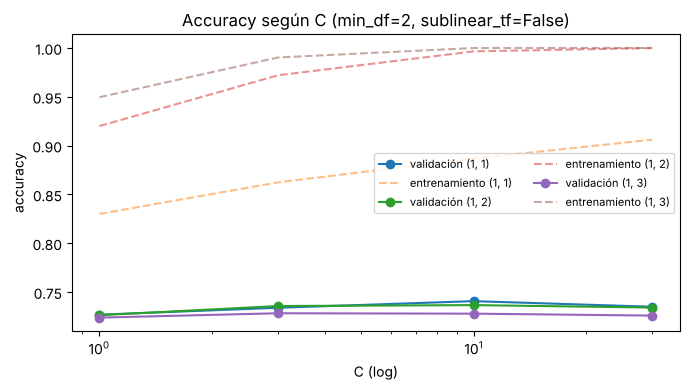

In [26]:
# Cómo cambia la accuracy con C para cada rango de n-gramas (min_df y sublinear_tf en su mejor valor)
mejor_min_df = busqueda.best_params_["vec__min_df"]
mejor_sublineal = busqueda.best_params_["vec__sublinear_tf"]
corte = malla_res[(malla_res["param_vec__min_df"] == mejor_min_df) & (malla_res["param_vec__sublinear_tf"] == mejor_sublineal)]

fig, ax = plt.subplots(figsize=(7, 4))
for ngramas, grupo in corte.groupby(corte["param_vec__ngram_range"].astype(str)):
    ax.plot(grupo["param_clf__C"], grupo["mean_test_score"], marker="o", label=f"validación {ngramas}")
    ax.plot(grupo["param_clf__C"], grupo["mean_train_score"], ls="--", alpha=0.5, label=f"entrenamiento {ngramas}")
ax.set_xscale("log"); ax.set_xlabel("C (log)"); ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy según C (min_df={mejor_min_df}, sublinear_tf={mejor_sublineal})")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

**Resultado** - **Mejores hiperparámetros:** unigramas, `min_df = 2`, `sublinear_tf = False`, `C = 10` → **0,7407 ± 0,0086**. Es prácticamente la misma configuración que se eligió a mano en la sección 5 (0,7401, que solo difiere en `sublinear_tf`).
- **Mejora frente al valor por defecto:** +1,5 puntos sobre TF-IDF + logística por defecto (0,7252). Casi toda la mejora viene de `C` (regularizar menos) y de `min_df = 2`.
- **Meseta:** las 10 mejores combinaciones están entre 0,7356 y 0,7407 (medio punto). Ningún ajuste de hiperparámetros rompe el techo de ~0,74, lo que confirma que el límite es la representación.
- **Sobreajuste:** la accuracy de entrenamiento (0,887) es 15 puntos mayor que la de validación (0,741). Con bigramas la brecha crece mucho: 0,997 en entrenamiento para 0,737 en validación, es decir, el modelo memoriza el entrenamiento sin generalizar mejor. En la gráfica se ve que subir `C` (regularizar menos) siempre sube la línea de entrenamiento, pero la de validación deja de mejorar a partir de `C = 10`.

**Modelo elegido:** TF-IDF de unigramas (`min_df = 2`) + regresión logística (`C = 10`).

## 8. Evaluación y análisis de errores
Todo en esta sección se hace con predicciones de validación cruzada sobre entrenamiento (`cross_val_predict`: cada reseña se predice con un modelo que no la vio). La prueba sigue sin tocarse.

### 8.1 Matriz de confusión y métricas por clase

Accuracy (validación cruzada): 0.7407

              precision    recall  f1-score   support

    negativo      0.641     0.623     0.632      3369
     neutral      0.978     0.997     0.987      2861
    positivo      0.634     0.641     0.638      3370

    accuracy                          0.741      9600
   macro avg      0.751     0.754     0.752      9600
weighted avg      0.739     0.741     0.740      9600



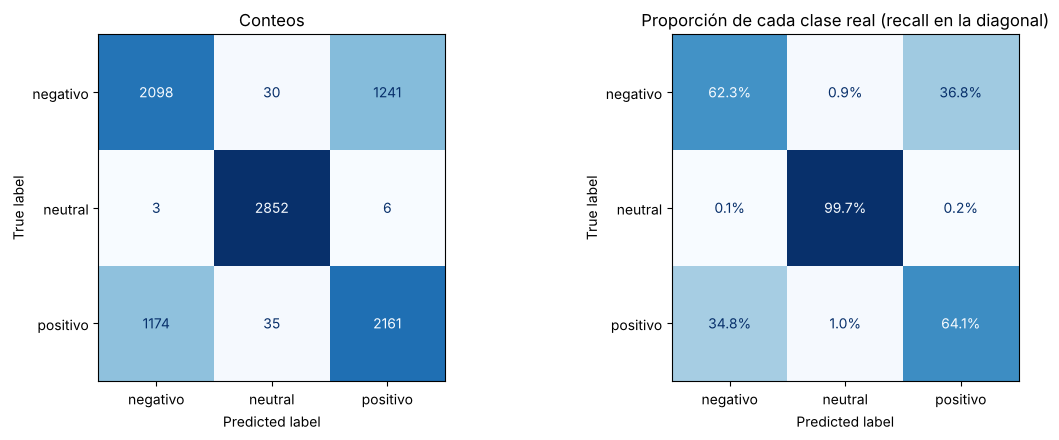

In [27]:
modelo_final = clone(busqueda.best_estimator_)
pred_cv = cross_val_predict(modelo_final, X_ent, y_ent, cv=CV, n_jobs=-1)

print(f"Accuracy (validación cruzada): {accuracy_score(y_ent, pred_cv):.4f}\n")
print(classification_report(y_ent, pred_cv, labels=LABELS, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_ent, pred_cv, labels=LABELS, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Conteos")
ConfusionMatrixDisplay.from_predictions(y_ent, pred_cv, labels=LABELS, normalize="true", values_format=".1%",
                                        ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Proporción de cada clase real (recall en la diagonal)")
plt.tight_layout(); plt.show()

**Cómo se lee** | Clase | Precisión | Recall | F1 |
|---|---|---|---|
| negativo | 0,641 | 0,623 | 0,632 |
| neutral | 0,978 | **0,997** | **0,987** |
| positivo | 0,634 | 0,641 | 0,638 |

- **`neutral` está resuelta:** el modelo encuentra el 99,7 % de las neutrales y casi no confunde otras reseñas con ellas. Su vocabulario es distinto (describe el producto en vez de opinar), y eso una bolsa de palabras lo capta bien.
- **Todo el error está entre `positivo` y `negativo`:** de los 2.489 errores, 1.241 son negativas predichas como positivas y 1.174 positivas predichas como negativas (el 97 % de los errores). Entre esas dos clases el modelo acierta solo un ~63 %, no mucho mejor que lanzar una moneda (50 %).
- La accuracy sola (0,741) escondía esto: un modelo con 0,74 suena "regular" en todas las clases, pero en realidad es casi perfecto en una y flojo en las otras dos.

### 8.2 Qué aprendió el modelo
Los coeficientes de la regresión logística dicen cuánto empuja cada término hacia cada clase. Se entrena el modelo con todo el conjunto de entrenamiento (sin la prueba) y se muestran los 15 términos con más peso por clase.

In [28]:
modelo_final.fit(X_ent, y_ent)
terminos = modelo_final.named_steps["vec"].get_feature_names_out()
coeficientes = modelo_final.named_steps["clf"].coef_

pesos = pd.DataFrame({
    clase: [f"{terminos[j]} ({coeficientes[k, j]:.1f})" for j in np.argsort(coeficientes[k])[::-1][:15]]
    for k, clase in enumerate(modelo_final.named_steps["clf"].classes_)
})
print(f"Términos en el vocabulario: {len(terminos)}")
pesos

Términos en el vocabulario: 2967


,negativo,neutral,positivo
0,mal (7.8),color (4.8),sola (6.9)
1,regalado (6.8),tamanos (4.4),acierto (6.6)
2,defraudo (6.4),trae (3.7),feliz (6.2)
3,vale (6.4),todavia (3.6),estrellas (6.0)
4,decepciono (5.8),litio (3.5),pena (5.8)
5,harto (5.8),kilo (3.4),verdad (5.6)
6,error (5.0),voltios (3.4),respondio (5.5)
7,resulto (5.0),unidades (3.4),supero (5.4)
8,debajo (4.8),solo (3.4),encanto (5.4)
9,molesto (4.5),usb (3.3),maravilla (5.3)


**Cómo se lee** - **`neutral`** se reconoce por vocabulario descriptivo del producto: "color", "tamanos", "trae", "litio", "kilo", "voltios", "unidades", "usb", "paquete". Coincide con lo que mostró el EDA (sección 3.6).
- **`positivo`** y **`negativo`** tienen palabras de opinión con sentido claro: "acierto", "feliz", "encanto", "maravilla", "supero" frente a "mal", "defraudo", "decepciono", "harto", "arrepiento", "defectuosa".
- **Pero varias palabras solo tienen sentido dentro de una expresión**, que la bolsa de palabras rompe: "regalado" es negativa porque viene de "no lo volveria a comprar ni regalado"; "vale" es negativa por "no vale lo que cuesta"; "pena" es positiva por "vale la pena"; "estrella" (singular) es negativa y "estrellas" (plural) positiva por "una estrella" frente a "cinco estrellas". El modelo aprendió las expresiones a través de una sola de sus palabras, lo que funciona en el promedio pero falla cuando la palabra aparece en otro contexto (se demuestra en la sección 10).
- "pero" está entre las palabras más negativas: las reseñas negativas tienden a terminar con "pero" + queja. Es lo más cerca que llega el modelo a capturar el orden, y solo funciona en parte.

### 8.3 Lectura de errores
Se leen 30 reseñas mal clasificadas (elegidas al azar con la semilla fija) junto con la probabilidad que les dio el modelo.

In [29]:
errores = pd.DataFrame({"text": X_ent, "real": y_ent, "predicha": pred_cv})
errores = errores[errores["real"] != errores["predicha"]]
print(f"Errores: {len(errores)} de {len(X_ent)} ({len(errores) / len(X_ent):.1%})\n")
print("Errores por par (real -> predicha):")
display(errores.groupby(["real", "predicha"]).size().rename("reseñas").to_frame())

for i, fila in errores.sample(30, random_state=SEED).iterrows():
    print(f"[{i}] real={fila['real']} | predicha={fila['predicha']}\n    {fila['text']}\n")

Errores: 2489 de 9600 (25.9%)

Errores por par (real -> predicha):


reseñas
real     predicha         
negativo neutral        30
         positivo     1241
neutral  negativo        3
         positivo        6
positivo negativo     1174
         neutral        35

[3198] real=negativo | predicha=positivo
    Me llego el reloj un martes por la manana, dos dias despues de pedirlo, en caja sellada. Lo uso sobre todo para caminar por las tardes y para recibir llamadas cuando estoy en la cocina. La pantalla se mantuvo redonda con el uso diario. Eso si, despues de unas semanas probandolo, la duracion de la carga quedo ordinaria para el precio que tiene.

[9239] real=positivo | predicha=negativo
    Compré esto a inicios de año por internet y llegó en unos cuatro días a mi casa. Desde que lo compré, lo tengo funcionando sin parar. El ensamblaje terminó siendo endeble para lo que cuesta. Lo armé un domingo por la tarde en la sala, nada del otro mundo. La uso en la oficina de mi casa casi todos los días y la app del fabricante terminó siendo sólida según lo que buscaba.

[9928] real=negativo | predicha=positivo
    Lo compré hace unos tres meses en una tienda por línea y llegó en cuatro días. Ya con un tiempo de uso, lo pruebo casi todos los días en las 

**Tipos de error encontrados**

Se leyeron las 30 reseñas y se agruparon según qué hace falta para clasificarlas bien. Algunas tienen además errores de tipeo ("cumplidoor", "medai", "dis") que dejan palabras fuera del vocabulario.

| Tipo de error | Cuántas (de 30) | Ejemplo | Cambio propuesto |
|---|---|---|---|
| **Dos opiniones opuestas y decide la última** (después de "aun así", "pero", "eso sí", "al final", "lo único es que") | 15 | [5057] *"...la instalación me pareció sobresaliente... Aun así, el sonido se mantuvo desagradable"* → real negativo, predicho positivo | Darle al modelo información de **posición**: por ejemplo, vectorizar aparte la última oración o lo que va después del último conector. Sale del enfoque convencional (texto completo como bolsa de palabras); en la Parte 2, un modelo secuencial (RNN/LSTM) lee el orden directamente. |
| **Dos opiniones unidas por "por otro lado", "además" o "y", y decide la primera** (a veces cierra con "tengo sentimientos encontrados" o "ni lo mejor ni lo peor") | 9 | [9174] *"no paré de tener problemas con la terminación... Por otro lado, me alegra haber elegido el motor"* → real negativo, predicho positivo | El mismo cambio de posición, más una lista de conectores que distinga los **contrastivos** ("aun así": gana lo que sigue) de los **aditivos** ("por otro lado": no). |
| **Negación** que invierte una palabra polar | 3 | [7884] *"por lo que pagué no me quejo en nada"* → real positivo, predicho negativo ("quejo" pesa hacia negativo) | Marcar las palabras que siguen a "no" (por ejemplo, "no me quejo" → `no_quejo`). Los bigramas lo intentan, pero en 5.3 no mejoraron el total. |
| **Una sola opinión, con una palabra poco frecuente**, rodeada de relleno | 3 | [2543] *"la conexión se sintió robusta hasta ahora"* → real positivo, predicho negativo | N-gramas de caracteres (`analyzer="char_wb"`) para compartir información entre variantes y errores de tipeo; más datos. |

**Conclusión del análisis de errores:** 24 de los 30 errores (80 %) se deben a **qué opinión va primero o después**. Ninguna representación de bolsa de palabras ni ningún clasificador de la sección 5 puede verlo, porque al pasar a la bolsa ese orden ya se perdió. Los cambios propuestos para los otros tipos (negación y palabras raras) afectan a pocas reseñas, así que no moverían el techo de ~0,74.

## 9. Modelo final
### 9.1 Evaluación en la prueba (una sola vez)
El modelo elegido (TF-IDF + regresión logística con los hiperparámetros de la sección 7), entrenado con las 9.600 reseñas de entrenamiento, se evalúa **una sola vez** en las 2.400 reseñas de prueba apartadas en 4.1. Después de esto no se cambia nada del modelo.

Accuracy en validación cruzada: 0.7407
Accuracy en la prueba:          0.7392



              precision    recall  f1-score   support

    negativo      0.638     0.623     0.630       843
     neutral      0.977     1.000     0.988       715
    positivo      0.632     0.634     0.633       842

    accuracy                          0.739      2400
   macro avg      0.749     0.752     0.751      2400
weighted avg      0.737     0.739     0.738      2400



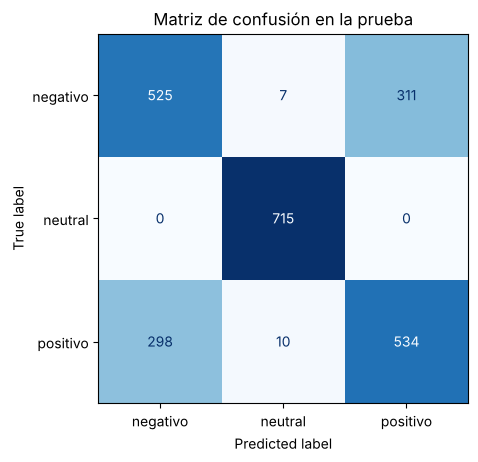

In [30]:
pred_prueba = modelo_final.predict(X_prueba)  # modelo_final ya está entrenado con X_ent (sección 8.2)
acc_prueba = accuracy_score(y_prueba, pred_prueba)
print(f"Accuracy en validación cruzada: {busqueda.best_score_:.4f}")
print(f"Accuracy en la prueba:          {acc_prueba:.4f}\n")
print(classification_report(y_prueba, pred_prueba, labels=LABELS, digits=3))

ConfusionMatrixDisplay.from_predictions(y_prueba, pred_prueba, labels=LABELS, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión en la prueba"); plt.show()

**Resultado** | | Accuracy | F1 negativo | F1 neutral | F1 positivo |
|---|---|---|---|---|
| Validación cruzada (entrenamiento) | 0,7407 | 0,632 | 0,987 | 0,638 |
| **Prueba (una sola vez)** | **0,7392** | 0,630 | 0,988 | 0,633 |

- La prueba da **0,15 puntos menos** que la validación cruzada, una diferencia mucho menor que su margen de error (≈ ±0,9 puntos con 2.400 reseñas).
- **Es esperable que la prueba dé un poco menos:** los hiperparámetros se eligieron por ser los que mejor resultado daban en validación cruzada entre 72 combinaciones, así que ese 0,7407 es un poco optimista (se escogió el máximo, que incluye algo de suerte). La prueba no participó en ninguna decisión, así que es la estimación honesta.
- Que las dos cifras casi coincidan indica que no hubo sobreajuste a la validación y que se puede esperar un score de Kaggle cercano a **0,74**.
- Las métricas por clase se repiten: `neutral` casi perfecta (recall 1,000) y `positivo`/`negativo` alrededor de 0,63.

### 9.2 Reentrenamiento, envío y guardado
Se reentrena el modelo final con **todo** `train.csv` (entrenamiento + prueba: 12.000 reseñas), se genera el envío y se guarda el modelo con `joblib` en `models/`.

> El modelo entregado en Bloque Neón debe ser el del **mejor score público** del grupo en Kaggle. Si al subir los cinco envíos otro archivo obtiene mejor score público, hay que guardar ese modelo en lugar de este (el `Pipeline` de cada envío está en las celdas de las secciones 5.6 y 6).

In [31]:
RUTA_MODELO = MODEL_DIR / "parte1_convencional.joblib"
NOMBRE_ENVIO = "conv05_lr_ajustada"

modelo_entregado, envio_final = generar_envio(
    busqueda.best_estimator_, NOMBRE_ENVIO,
    f"TF-IDF + LR ajustada con GridSearchCV {busqueda.best_params_}", "LR ajustada con GridSearchCV")
joblib.dump(modelo_entregado, RUTA_MODELO)
print(f"Modelo guardado en {RUTA_MODELO} ({RUTA_MODELO.stat().st_size / 1e6:.1f} MB)")
modelo_entregado

Guardado submissions/conv05_lr_ajustada.csv | predicciones por clase: {'positivo': 1093, 'negativo': 1072, 'neutral': 835}
Modelo guardado en models/parte1_convencional.joblib (0.1 MB)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vec', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negativo','neutral','positivo']"
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function cor...x7f92814c4180>
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


### 9.3 Prueba de replicabilidad
Se carga el modelo guardado y se comprueba que sus predicciones sobre `eval.csv` son idénticas a las del archivo de envío. El modelo recibe el texto original: la corrección de 3.7 va dentro del vectorizador, así que basta con tener definidas en el notebook las funciones `corregir_texto` y `reparar_par` (y sus constantes) antes de cargarlo.

In [32]:
modelo_cargado = joblib.load(RUTA_MODELO)
pred_cargado = modelo_cargado.predict(eval_df["text"])
envio_guardado = pd.read_csv(SUB_DIR / f"{NOMBRE_ENVIO}.csv")

assert (envio_guardado["id"].values == eval_df["id"].values).all()
assert (envio_guardado["answer"].values == pred_cargado).all()
print("Las predicciones del modelo cargado coinciden con el envío en las", len(pred_cargado), "reseñas de eval.")

Las predicciones del modelo cargado coinciden con el envío en las 3000 reseñas de eval.


## 10. Bitácora de envíos y conclusiones
Mínimo **5 envíos distintos** a Kaggle. Los cinco archivos de esta versión ya están en `submissions/`; falta subirlos y anotar el score público.

| # | Archivo | Modelo / cambio | Accuracy CV | Score público Kaggle |
|---|---|---|---|---|
| 1 | `conv01_tfidf_lr.csv` | TF-IDF por defecto + regresión logística por defecto | 0,7252 | _pendiente_ |
| 2 | `conv02_tfidf_min_df2_lr.csv` | TF-IDF sublineal, unigramas, `min_df=2` + LR (`C=10`) | 0,7401 | _pendiente_ |
| 3 | `conv03_tfidf_min_df2_svm.csv` | Misma representación + SVM lineal (`C=0.3`) | 0,7323 | _pendiente_ |
| 4 | `conv04_stacking.csv` | Stacking (LR + SVM + NB → LR) | 0,7420 | _pendiente_ |
| 5 | `conv05_lr_ajustada.csv` | LR ajustada con `GridSearchCV` (unigramas, `min_df=2`, `C=10`) — **modelo final** | 0,7407 | _pendiente_ |

Línea base del curso en Kaggle: _TODO_

Si un envío distinto del 5 obtiene el mejor score público, el modelo que se entrega es el de ese envío (ver 9.2). El score privado decide la clasificación final, así que entre envíos con scores públicos casi iguales conviene confiar más en la validación cruzada.

In [33]:
display(pd.DataFrame(bitacora).assign(**{"score público Kaggle": "pendiente"}))

print("Todos los experimentos, de mejor a peor (validación cruzada sobre entrenamiento):")
todos = pd.DataFrame(experimentos).sort_values("accuracy", ascending=False).round(4).reset_index(drop=True)
todos

,archivo,modelo / cambio,accuracy CV,score público Kaggle
0,conv01_tfidf_lr.csv,TF-IDF por defecto + regresión logística por d...,0.7252,pendiente
1,conv02_tfidf_min_df2_lr.csv,"TF-IDF sublineal, unigramas, min_df=2 + LR (C=10)",0.7401,pendiente
2,conv03_tfidf_min_df2_svm.csv,"TF-IDF sublineal, unigramas, min_df=2 + Linear...",0.7323,pendiente
3,conv04_stacking.csv,Stacking (LR + SVM + NB -> LR) sobre TF-IDF su...,0.7420,pendiente
4,conv05_lr_ajustada.csv,TF-IDF + LR ajustada con GridSearchCV {'clf__C...,0.7407,pendiente


Todos los experimentos, de mejor a peor (validación cruzada sobre entrenamiento):


,sección,experimento,accuracy,desv. accuracy,F1 macro,segundos,representación,C,min_df,términos,n_gramas
0,6,Stacking (LR + SVM + NB -> LR),0.7420,0.0132,0.7540,5.5536,NaN,NaN,NaN,NaN,NaN
1,7,LR ajustada con GridSearchCV,0.7407,0.0086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.2b,TF-IDF sublineal (min_df=2) + LR (C=10),0.7401,0.0090,0.7515,2.0028,NaN,NaN,2.0,2967.0,NaN
3,5.3,"TF-IDF sublineal (1, 1) + LR (C=10)",0.7401,0.0090,0.7515,1.7584,NaN,10.0,NaN,2967.0,"(1, 1)"
4,5.4c,Sin stemming,0.7401,0.0090,0.7515,1.7380,NaN,NaN,NaN,2967.0,NaN
5,5.4a,"Tokens: por defecto: palabras y números, sin s...",0.7401,0.0090,0.7515,1.7949,NaN,NaN,NaN,NaN,NaN
6,5.5,Regresión logística (C=10),0.7401,0.0090,0.7515,1.8849,NaN,NaN,NaN,NaN,NaN
7,5.4b,Palabras vacías: no quitar palabras vacías,0.7401,0.0090,0.7515,1.7783,NaN,NaN,NaN,NaN,NaN
8,5.4a,"Tokens: palabras, números y signos",0.7400,0.0085,0.7514,1.7929,NaN,NaN,NaN,NaN,NaN
9,5.4a,"Tokens: solo palabras, sin números",0.7379,0.0091,0.7493,1.6571,NaN,NaN,NaN,NaN,NaN


### Límites de la bolsa de palabras
El curso cierra la Parte 1 con tres límites de estas representaciones: **no ven el orden, no entienden la negación y no conocen sinónimos**. Se demuestran con el modelo entregado.

In [34]:
def probabilidades(textos):
    return pd.DataFrame(modelo_entregado.predict_proba(textos), index=textos,
                        columns=modelo_entregado.classes_).round(3)


print("1) ORDEN: mismas opiniones, en orden inverso. Una persona leería la primera como negativa y la segunda como positiva.")
display(probabilidades([
    "La bateria dura muchisimo y la pantalla es preciosa. Aun asi, se rompio a la semana y no lo recomiendo.",
    "Se rompio a la semana y no lo recomiendo. Aun asi, la bateria dura muchisimo y la pantalla es preciosa.",
]))

print("2) NEGACIÓN: agregar 'no' invierte el sentido, pero en la bolsa solo agrega una columna más.")
display(probabilidades(["Me encanto, lo recomiendo.", "No me encanto, no lo recomiendo.",
                        "Es una maravilla, estoy feliz con la compra.",
                        "No es una maravilla, no estoy feliz con la compra."]))
peso_no = modelo_entregado.named_steps["clf"].coef_[:, modelo_entregado.named_steps["vec"].vocabulary_["no"]]
print("   Peso de 'no' hacia cada clase:", {c: round(float(w), 2) for c, w in zip(modelo_entregado.classes_, peso_no)})
print("   Y al revés: 'vale' casi siempre aparece en 'no vale lo que cuesta', así que el modelo la aprendió como negativa.")
display(probabilidades(["Vale cada peso.", "No vale lo que cuesta."]))

print("3) SINÓNIMOS: palabras que no aparecen en entrenamiento no tienen columna en la bolsa de palabras.")
vocabulario = modelo_entregado.named_steps["vec"].vocabulary_
for palabra in ["excelente", "estupendo", "fenomenal", "espectacular", "magnifico"]:
    print(f"   '{palabra}' en el vocabulario: {palabra in vocabulario}")
display(probabilidades(["El producto es excelente.", "El producto es fenomenal.", "El producto es magnifico."]))

1) ORDEN: mismas opiniones, en orden inverso. Una persona leería la primera como negativa y la segunda como positiva.


,negativo,neutral,positivo
"La bateria dura muchisimo y la pantalla es preciosa. Aun asi, se rompio a la semana y no lo recomiendo.",0.55,0.008,0.442
"Se rompio a la semana y no lo recomiendo. Aun asi, la bateria dura muchisimo y la pantalla es preciosa.",0.55,0.008,0.442


2) NEGACIÓN: agregar 'no' invierte el sentido, pero en la bolsa solo agrega una columna más.


,negativo,neutral,positivo
"Me encanto, lo recomiendo.",0.007,0.000,0.993
"No me encanto, no lo recomiendo.",0.036,0.006,0.958
"Es una maravilla, estoy feliz con la compra.",0.004,0.000,0.996
"No es una maravilla, no estoy feliz con la compra.",0.013,0.004,0.983


   Peso de 'no' hacia cada clase: {'negativo': -0.43, 'neutral': 2.8, 'positivo': -2.36}
   Y al revés: 'vale' casi siempre aparece en 'no vale lo que cuesta', así que el modelo la aprendió como negativa.


,negativo,neutral,positivo
Vale cada peso.,0.996,0.0,0.004
No vale lo que cuesta.,1.000,0.0,0.000


3) SINÓNIMOS: palabras que no aparecen en entrenamiento no tienen columna en la bolsa de palabras.
   'excelente' en el vocabulario: True
   'estupendo' en el vocabulario: True
   'fenomenal' en el vocabulario: False
   'espectacular' en el vocabulario: True
   'magnifico' en el vocabulario: False


,negativo,neutral,positivo
El producto es excelente.,0.022,0.093,0.884
El producto es fenomenal.,0.257,0.659,0.084
El producto es magnifico.,0.257,0.659,0.084


### Conclusiones finales
- **Mejor modelo:** TF-IDF de unigramas (`min_df = 2`) + regresión logística (`C = 10`): **0,7407** en validación cruzada y **0,7392** en la prueba, frente al 0,351 del modelo trivial. Se eligió por tener el mejor resultado entre los modelos simples, empatar con el stacking dentro del margen de error, entrenar en un par de segundos, pesar 0,1 MB y poder interpretarse.
- **Qué aportó cada decisión** (validación cruzada sobre entrenamiento):

| Decisión | Efecto |
|---|---|
| Subir `C` de 1 a 10 en TF-IDF | +1,1 puntos (0,7252 → 0,7365) |
| `min_df = 2` | +0,45 puntos (0,7356 → 0,7401) |
| Bigramas / trigramas | −0,5 / −1,1 puntos |
| Quitar palabras vacías (lista completa) | −0,8 puntos |
| Stemming (Snowball) | −0,7 puntos |
| Signos como términos / quitar números | 0,0 / −0,2 puntos |
| Mejor clasificador no lineal (Gradient Boosting) | −3,6 puntos frente a la logística |
| Stacking | +0,2 puntos (no significativo) |
| Búsqueda en malla | +0,06 puntos sobre la elección manual |

- **El techo es la representación, no el modelo.** Con cualquier combinación de representación, preprocesamiento, clasificador o ensamble, el resultado queda en ~0,74. `neutral` está resuelta (F1 0,99), y todo el margen está en separar `positivo` de `negativo` (F1 ~0,63), que usan el mismo vocabulario y se distinguen por el **orden** de las opiniones.
- **Lo que este modelo no puede hacer** (demostrado arriba con el modelo entregado):
  - **Orden:** las dos reseñas con las mismas opiniones en orden inverso reciben exactamente la misma probabilidad (0,550 / 0,008 / 0,442), aunque una persona las clasificaría al revés. Es el error del 80 % de las reseñas mal clasificadas en 8.3.
  - **Negación:** *"No me encanto, no lo recomiendo"* sigue siendo positiva con 0,958. El modelo no aprendió "no" como inversor: su peso empuja hacia `neutral` (+2,8) y no hacia `negativo` (−0,4). Al revés, *"Vale cada peso"* sale negativa con 0,996 porque "vale" casi siempre aparece en "no vale lo que cuesta".
  - **Sinónimos y palabras nuevas:** "fenomenal" y "magnifico" no están en el vocabulario, así que *"El producto es fenomenal"* queda como una reseña sin opinión y se clasifica `neutral` (0,659), mientras que *"El producto es excelente"* es positiva (0,884). Para la bolsa de palabras, dos palabras distintas no tienen nada en común aunque signifiquen lo mismo. Lo mismo pasa con los errores de tipeo.
- **Por qué esto motiva la Parte 2:** un modelo secuencial (RNN, LSTM, GRU) lee la reseña en orden y puede aprender que lo que viene después de "aun así" pesa más, o que "no" invierte lo que sigue. Los *embeddings* preentrenados dan vectores parecidos a sinónimos como "excelente", "fenomenal" y "magnifico". Son justamente los tres límites que la bolsa de palabras no puede superar.

## 11. Declaración de uso de IA generativa
El curso pide, para el proyecto, declarar el uso de IA generativa y anexar los prompts.

| Pregunta | Respuesta |
|---|---|
| ¿Qué herramienta se usó? (nombre y versión) | Claude Code (Anthropic), asistente de programación con IA generativa. _TODO: versión_ |
| ¿Para qué se usó? | Para generar esta versión "convencional" del notebook a partir del esqueleto del grupo (secciones 1 a 3.7, con el EDA y la corrección de datos) y de una tabla con los pasos vistos en clase (línea base, limpieza, palabras vacías, raíces, representación, modelos, validación, evaluación, límites). |
| ¿Qué parte del trabajo resultó de ella? | El código y los textos de las secciones 4 a 10, la lista de palabras vacías de 5.4 y las conclusiones del EDA. |
| ¿Cómo se verificó lo que produjo? | El notebook se ejecutó completo de principio a fin sin errores, y la prueba de replicabilidad (9.3) confirma que el modelo guardado reproduce el envío. _TODO: el grupo debe revisar y volver a ejecutar cada celda, comprobar los números y poder explicar cada decisión en la sustentación._ |

Anexo de prompts: _TODO (archivo o enlace)_